# <u>Multiple Linear Regression</u>

## Topics

* [1. Problem setup](#setup)
* [2. Assumptions for Simple Linear Regression](#assume)
* [3. Core Minimization problem (OLS)](#min)
* [4. Model Quality](#quality)
* [5. Statistical Inference](#stats)
* [6. (Batch) Gradient Descent](#gd)
* [7. Stochastic Gradient Descent (SGD)](#sgd)
* [8. Limitations](#limits)



In [2]:
import numpy as np # for random numbers and matrix calculus
import matplotlib.pyplot as plt # for plotting
import pandas as pd # for creating dataframes
import scipy.stats as stats # for Q-Q Plot
import statsmodels.api as sm # # for Statistical Inference
from scipy.stats import t,f # for Students t and F distribtuion
from scipy import stats # or like this but then we have to write stats.
from scipy.stats import multivariate_normal # multivariate normal distribution
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple
import plotly.colors as pc # for more color variety using plotly.express as px
import seaborn as sns # for plotting
from statsmodels.stats.outliers_influence import variance_inflation_factor # for VIF factor

<a class="anchor" id="setup"></a>
## 1. Problem setup

In this notebook, I will introduce **Multiple Linear Regression**, a method used to predict a target (dependent variable) based on <u>multiple</u> features (independent variables).

The goal is to learn the relationship between the **features (predictors)** and the **target variable** using a linear model.

---

### Variables

* **$y$**: target vector of length $n$
* **$x_1$**: 1st feature vector of length $n$
* **$x_2$**: 2nd feature vector of length $n$
* $\vdots$
* **$x_p$**: $p$-th feature vector of length $n$

---

### Model (scalar form)

For each observation $i = 1, \dots, n$:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)} 
= \theta_0 + \theta_1 x_1^{(i)} + \ldots + \theta_p x_p^{(i)} + \varepsilon^{(i)}
$$

where:

- $\theta = (\theta_0, \theta_1, \ldots, \theta_p) \in \mathbb{R}^{p+1}$ is the parameter vector  
- $x^{(i)} = (1, x_1^{(i)}, \ldots, x_p^{(i)}) \in \mathbb{R}^{p+1}$ is the feature vector (including intercept)  
- $\varepsilon^{(i)}$ is the error term capturing noise or unobserved factors  

---

### Prediction Model

The estimated model is:

$$
\hat{y}^{(i)} = \hat{\theta}^\top x^{(i)} 
= \hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}, \hspace{2 mm} i = 1,...,n
$$

where:

- $\hat{\theta}=(\hat{\theta}_0, \hat{\theta}_1, \ldots, \hat{\theta}_p) \in \mathbb{R}^{p+1}$ are the estimated parameters  
- $\hat{\theta}_j$ represents the effect of feature $x_j$ on the target $j=1,...,p$  
- $\hat{\theta}_0$ is the intercept (baseline prediction when all features are zero)  

---

### Matrix Formulation

We can express the model compactly using matrix notation:

$$
\underbrace{\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)} 
\end{pmatrix}}_y =

\begin{pmatrix}
\theta_0 + \theta_1 x_1^{(1)} + \ldots + \theta_p x_p^{(1)} + \varepsilon^{(1)} \\
\theta_0 + \theta_1 x_1^{(2)} + \ldots + \theta_p x_p^{(2)} + \varepsilon^{(2)} \\
\vdots \\
\theta_0 + \theta_1 x_1^{(n)} + \ldots + \theta_p x_p^{(n)} + \varepsilon^{(n)} 
\end{pmatrix} \\ \Leftrightarrow

y = \theta_0 \cdot 1_n + \theta_1 \cdot \underbrace{\begin{pmatrix} x_1^{(1)} \\ x_1^{(2)} \\ \vdots \\ x_1^{(n)} \end{pmatrix}}_{x_1} + \theta_2 \cdot \underbrace{\begin{pmatrix} x_2^{(1)} \\ x_2^{(2)} \\ \vdots \\ x_2^{(n)} \end{pmatrix}}_{x_2} + \ldots + 
\theta_p \cdot \underbrace{\begin{pmatrix} x_p^{(1)} \\ x_p^{(2)} \\ \vdots \\ x_p^{(n)} \end{pmatrix}}_{x_p} + \underbrace{\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}}_\varepsilon

\\[2 mm]
\\ \Leftrightarrow

y = \theta_0 \cdot 1_n + \left(\sum_{j=1}^p \theta_j \cdot x_j\right) + \varepsilon

\\[3mm]
\\ \Leftrightarrow 


y = X\theta + \varepsilon
$$

where:

$$
y =
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix}, 

\quad

X =
\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix},

\quad

\theta =
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix},

\quad

\varepsilon=
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
$$

---

### Predictions in Matrix Form

$$
\hat{y} = X\hat{\theta} = \hat{\theta}_0 \cdot 1_n + \sum_{j=1}^p \hat{\theta}_j \cdot x_j
$$

where:

$$
\hat{y} =
\begin{pmatrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(n)}
\end{pmatrix}
$$

---

### &#128161; Interpretation

- Each row of $X$ represents one observation  
- Each column (except the first) represents a feature  
- The first column of ones accounts for the intercept  
- The model is **linear in the parameters** (even if features are transformed)



<a class="anchor" id="assume"></a>
## 2. Assumptions for Multiple Linear Regression

| Assumption | Description | Consequence | Verification |
|-----------|------------|-------------|--------------|
| **Linearity** | The relationship between the predictors and the target is linear in the parameters: $y = X\theta + \varepsilon$. |  Ensures unbiased and consistent estimates of $\hat{\theta}$ | Residuals vs. Fitted Plot, Partial regression plots |
| <span style="color: yellow;"><strong>Independent Errors</strong></span> | Error terms are independent: $\varepsilon^{(i)}$ independent of $\varepsilon^{(j)}$ for $i \neq j$. |  Valid statistical inference (standard errors, hypothesis tests) | Residuals vs. Order Plot, Durbin–Watson test |
| **Homoscedasticity** | Constant variance of errors: $\mathrm{Var}(\varepsilon^{(i)}) = \sigma^2$ for all $i$; $\mathrm{Cov}(\varepsilon)=\sigma^2 I_n$ ,  $\sigma^2 \ge 0$ |  Correct standard errors and confidence intervals | Residuals vs. Fitted Plot |
| **Zero Mean Errors** | Errors are centered at zero: $\mathrm{E}[\varepsilon^{(i)}] = 0$. |  Ensures unbiasedness of $\hat{\theta}$ | Check mean of residuals (should be $\approx 0$) |
| <span style="color: yellow;"><strong>Normality of Errors</strong></span>  **$\color{yellow}\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)$** | Errors follow a normal distribution |  Enables exact inference (t-tests, F-tests, confidence intervals) | Q–Q plot of residuals, Histogram of residuals |
| **No Extreme Outliers / Influential Points** | No single observation should dominate the model fit. |  Stability of estimates and inference | Leverage plots, Cook’s distance, Residuals vs. Fitted |
| **Full Rank of $X$ (No Multicollinearity)** | The regression matrix $X$ has full column rank: $\text{rank}(X) = p+1 < n$. |  Unique solution $\hat{\theta} = (X^\top X)^{-1}X^\top y$ exists | Correlation matrix, Variance Inflation Factor (VIF) |


### Linearity

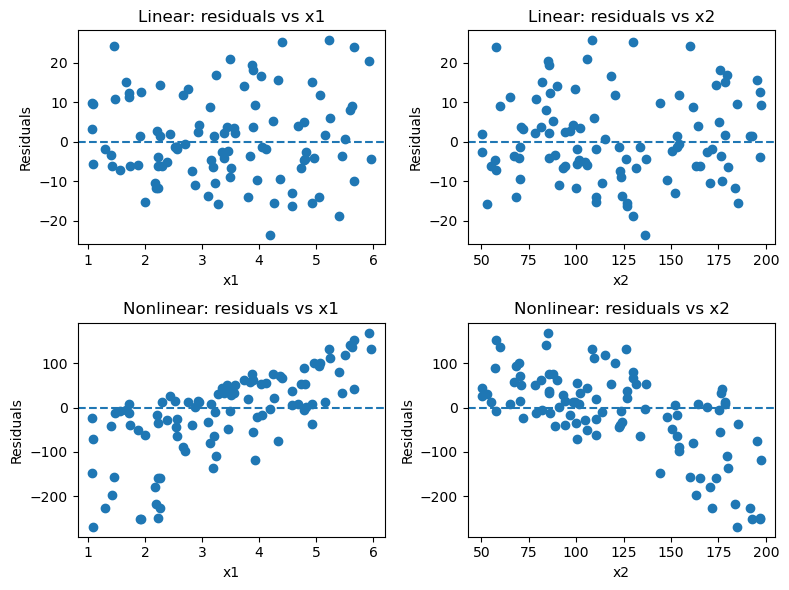

In [3]:
np.random.seed(1742) # for reproducibility of random numbers

n = 100 # number of observation/sample size

# Features
x_1 = np.random.uniform(1, 6, n) # e.g. number of rooms
x_2 = np.random.uniform(50, 200, n) # e.g. house size

X = np.column_stack([np.ones(n), x_1, x_2]) # regresion matrix

theta = np.array([5, 10, 0.5]) # parameter vector


# Linear data
true_y = X @ theta
error = np.random.normal(0, 10, n)
y = true_y + error

res = y - (X @ theta) # residuals


# Nonlinear data
true_y_nl = (
    5
    + 10 * x_1
    + 0.5 * x_2
    + 2 * (x_1**2) # curvature
    - 0.01 * (x_2**2) # curvature
    + 0.3 * (x_1 * x_2) # interaction
)

y_nl = true_y_nl + error

# linear model applied to nonlinear data to to show that a linear model is inappropriate
y_hat_linear = X @ theta
res_nl = y_nl - y_hat_linear


# 3D Plot Linear data
fig1 = px.scatter_3d(
    x=x_1, y=x_2, z=y,
    title="Linear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Create grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x_1.min(), x_1.max(), 20),
    np.linspace(x_2.min(), x_2.max(), 20)
)

grid_y = 5 + 10*grid_x1 + 0.5*grid_x2  # true linear model
grid_nonlinear= 5 + 10 * grid_x1 + 0.5 * grid_x2 + 2 * (grid_x1**2) - 0.01 * (grid_x2**2) + 0.3 * (grid_x1 * grid_x2)

# Add Regression plane
fig1.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Plane",
        showlegend=True # force to show legend
    )
)

fig1.update_layout(width=700, height=500)
fig1.show()


# 3D Plot Nonlinear data
fig2 = px.scatter_3d(
    x=x_1, y=x_2, z=y_nl,
    title="Nonlinear Data",
    labels={'x':'x1', 'y':'x2', 'z':'y'}
)

# Non linear plane
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_nonlinear,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Nonlinear Plane",
        showlegend=True  # force to show legend
    )
)

# Same linear plane (wrong model)
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="Linear Fit (Wrong Model)",
        showlegend=True # force to show legend 
    )
)


fig2.update_layout(width=700, height=500)
fig2.show()


# Residuals Plot
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# Linear case
axes[0,0].scatter(x_1, res)
axes[0,0].axhline(0, linestyle="--")
axes[0,0].set_title("Linear: residuals vs x1")
axes[0,0].set_xlabel("x1")
axes[0,0].set_ylabel("Residuals")

axes[0,1].scatter(x_2, res)
axes[0,1].axhline(0, linestyle="--")
axes[0,1].set_title("Linear: residuals vs x2")
axes[0,1].set_xlabel("x2")
axes[0,1].set_ylabel("Residuals")

# Nonlinear case
axes[1,0].scatter(x_1, res_nl)
axes[1,0].axhline(0, linestyle="--")
axes[1,0].set_title("Nonlinear: residuals vs x1")
axes[1,0].set_xlabel("x1")
axes[1,0].set_ylabel("Residuals")

axes[1,1].scatter(x_2, res_nl)
axes[1,1].axhline(0, linestyle="--")
axes[1,1].set_title("Nonlinear: residuals vs x2")
axes[1,1].set_xlabel("x2")
axes[1,1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Independent errors

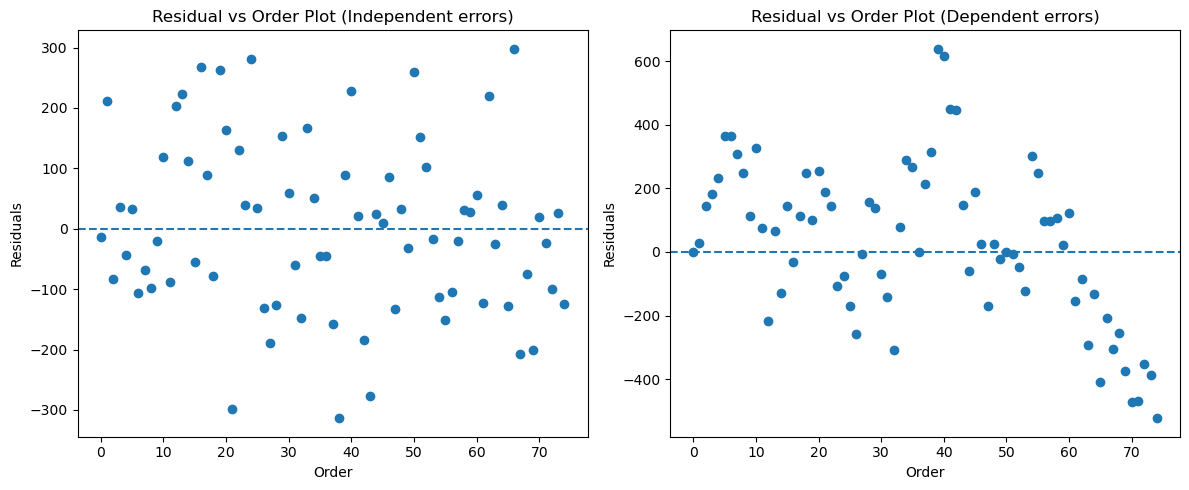

In [4]:
# Generate data
np.random.seed(2148) 
n = 75
x1 = np.random.randint(100,300,n) # kilometers
x2 = np.random.randint(2,20,n) # car ages in years
X = np.column_stack([np.ones(n),x1,x2]) # Regression matrix
theta = np.array([12, 4.5, 6]) # parameter vector
true_price = X @ theta
error_ind = np.random.normal(0,150,n) # independent errors
price = true_price + error_ind # distorted relationship using independent errors
res_ind = price - true_price # residuals of independent errors

# Dependent errors by creating autocorrelated errors (AR(1))
rho = 0.8
errors_dep = np.zeros(n)

for i in range(1, n):
    errors_dep[i] = rho * errors_dep[i-1] + np.random.normal(0, 150) # next error depends on previous one with formula error_i = p*error_i-1 + noise


price_ = true_price + errors_dep # distorted relationship using dependent errors
res_dep = price_ - true_price # residuals of dependent errors

#help(px.scatter_3d)

# Create grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 20),
    np.linspace(x2.min(), x2.max(), 20)
)

grid_y = 12 + 4.5*grid_x1 + 6*grid_x2  # true linear model

# Independent errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=price,
    title="Independent Errors",
    labels={'x':'Distance (km)', 'y':'Age', 'z':'Price'},
    color_discrete_sequence=['pink']  # all points 
)

# Add Regression plane
fig1.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        opacity=0.4, # color intensity of plane
        showscale=False, # hides scalebar
        name="True Plane",
        showlegend=True  
    )
)


fig1.update_layout(width=700, height=500)
fig1.show()


# Dependent errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=price_,
    title="Dependent Errors (Autocorrelation)",
    labels={'x':'Distance (km)', 'y':'Age', 'z':'Price'},
    color_continuous_scale='Viridis' # choose colormap
)

# Add Regression plane
fig2.add_traces(
    go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=grid_y,
        showscale=False, # hides scalebar
        opacity=0.4, # color intensity of plane
        name="True Plane",
        showlegend=True,
        colorscale='Blues' # change the plane color 
    )
)

fig2.update_layout(width=700, height=500)
fig2.show()


fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Independent errors
axes[0].scatter(range(n),res_ind)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residual vs Order Plot (Independent errors)")
axes[0].set_ylabel("Residuals")
axes[0].set_xlabel("Order")


# Dependent errors
axes[1].scatter(range(n),res_dep)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residual vs Order Plot (Dependent errors)")
axes[1].set_ylabel("Residuals")
axes[1].set_xlabel("Order")

plt.tight_layout()
plt.show()


### Homoskedasticity


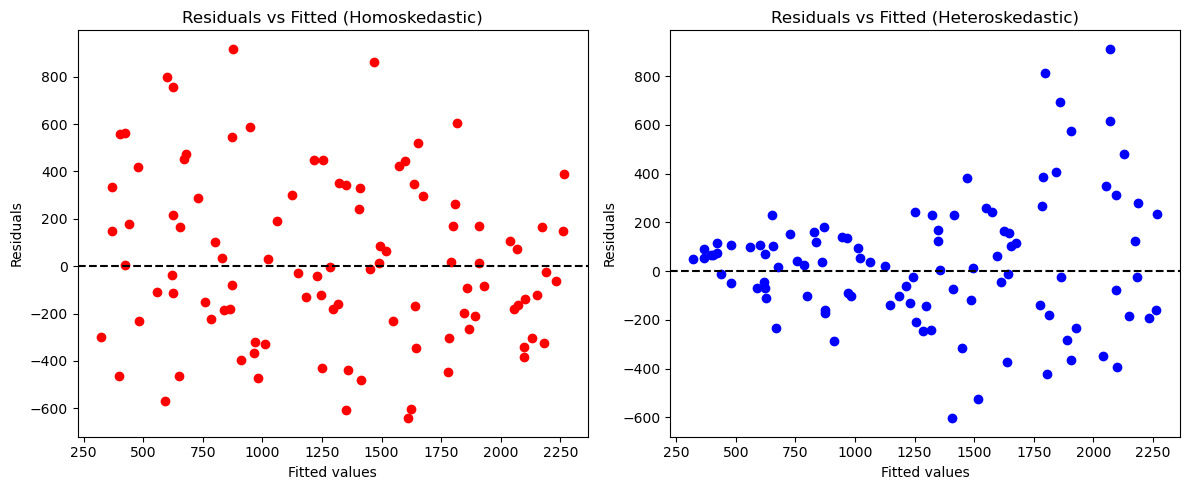

In [5]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Homoskedastic errors
error_homo = np.random.normal(0, 300, n)
y_homo = true_y + error_homo

# Heteroskedastic errors (variance changes)
error_hetero = np.random.normal(0, 0.5 + 2*(x1+x2), n)
y_hetero = true_y + error_hetero

# Residuals using true coefficients
res_homo = y_homo - true_y
res_hetero = y_hetero - (X @ theta) # true_y = X @ theta


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Homoskedastic
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_homo,
    title="Homoskedastic Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['red']
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Heteroskedastic
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_hetero,
    title="Heteroskedastic Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['blue']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()


# Residuals vs fitted values
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(true_y, res_homo, color='red')
axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title("Residuals vs Fitted (Homoskedastic)")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

axes[1].scatter(true_y, res_hetero, color='blue')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set_title("Residuals vs Fitted (Heteroskedastic)")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Zero Mean errors


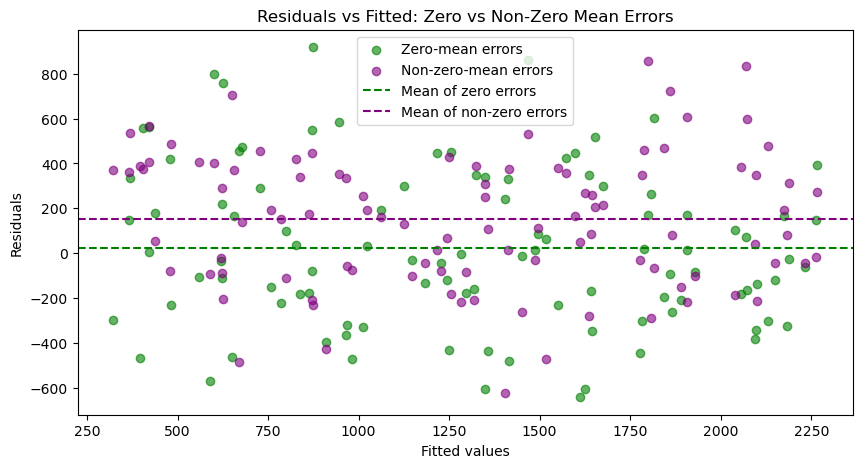

In [6]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Errors
error_zero_mean = np.random.normal(0, 300, n)
error_nonzero_mean = np.random.normal(100, 300, n) # mean = 100

# Observed values
y_zero = true_y + error_zero_mean
y_nonzero = true_y + error_nonzero_mean

# Residuals using true coefficients
res_zero = y_zero - true_y
res_nonzero = y_nonzero - true_y


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Zero-mean errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_zero,
    title="Homoskedastic Errors: Zero Mean",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['green']
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Non-zero mean errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_nonzero,
    title="Homoskedastic Errors: Non-Zero Mean",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['purple']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()

# Residuals vs fitted values
fitted = true_y  # linear model, fitted = true_y = X @ theta

plt.figure(figsize=(10,5))
plt.scatter(fitted, res_zero, color='green', alpha=0.6, label='Zero-mean errors')
plt.scatter(fitted, res_nonzero, color='purple', alpha=0.6, label='Non-zero-mean errors')

# Horizontal lines
plt.axhline(np.mean(error_zero_mean), linestyle='--', color='green', label='Mean of zero errors')
plt.axhline(np.mean(error_nonzero_mean), linestyle='--', color='purple', label='Mean of non-zero errors')

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted: Zero vs Non-Zero Mean Errors")
plt.legend()
plt.show()

### Normaility of errors

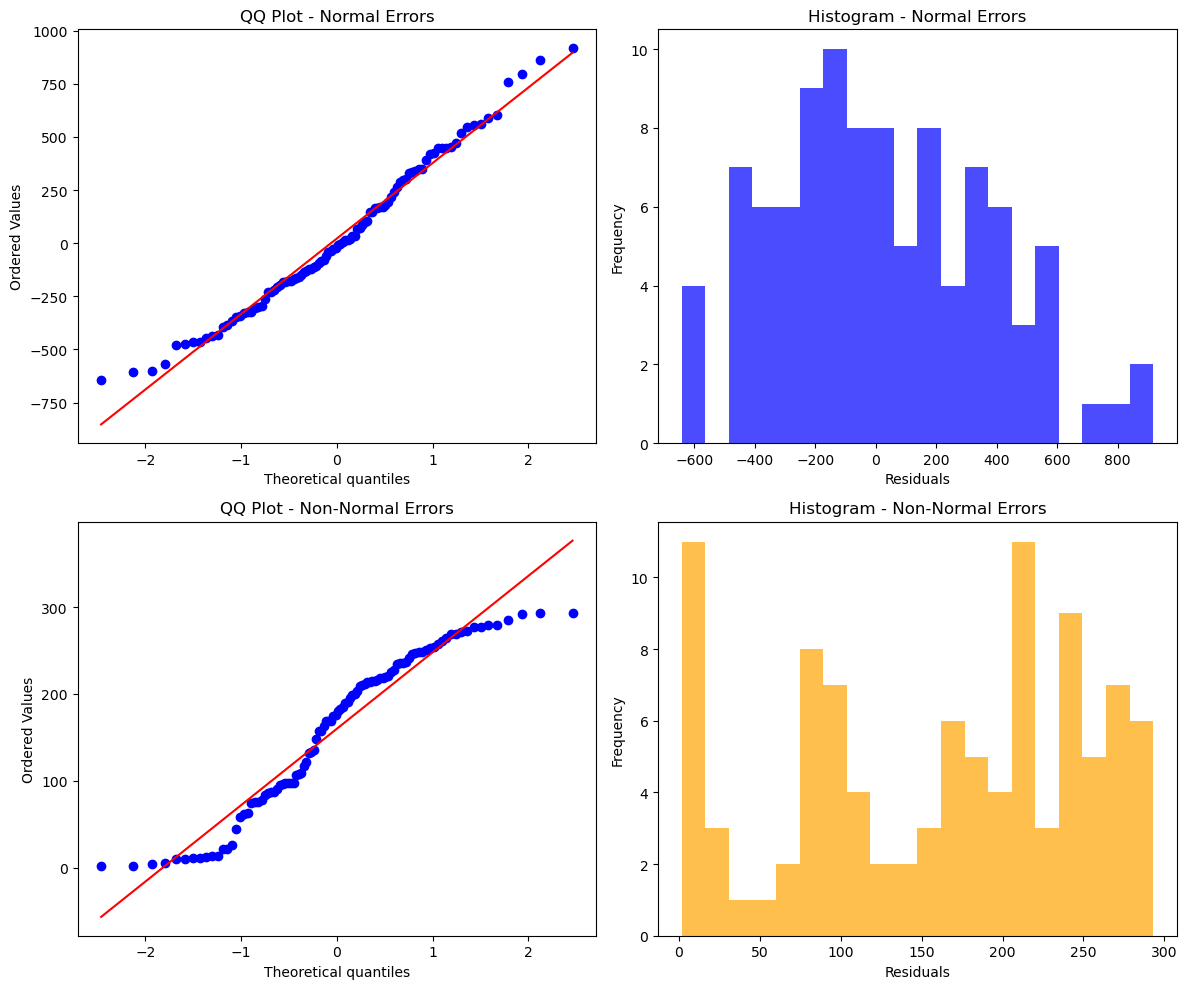

In [7]:
# Generate data
np.random.seed(2231)
n = 100

# Features
x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)
X = np.column_stack([np.ones(n), x1, x2])

# True coefficients
theta = np.random.randint(0, 20, 3)

# True target
true_y = X @ theta

# Errors
error_normal = np.random.normal(0, 300, n) # normal errors
error_non_normal = np.random.uniform(0,300,n) # uniform errors

# Observed values
y_normal = true_y + error_normal
y_non_normal = true_y + error_non_normal

# Residuals using true coefficients
res_normal = y_normal - true_y
res_non_normal = y_non_normal - true_y


# Create grid for surfaces
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)
grid_X = np.column_stack([np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()])
surface_true = (grid_X @ theta).reshape(grid_x1.shape)


# 3D scatterplots with regression plane
# Normal errors
fig1 = px.scatter_3d(
    x=x1, y=x2, z=y_normal,
    title="Normal Errors",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=["blue"]
)
fig1.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig1.update_layout(width=700, height=500)
fig1.show()

# Non-normal errors
fig2 = px.scatter_3d(
    x=x1, y=x2, z=y_non_normal,
    title="Non-Normal Errors (Heavy Tails)",
    labels={'x':'x1', 'y':'x2', 'z':'y'},
    color_discrete_sequence=['orange']
)
fig2.add_traces(go.Surface(
    x=grid_x1, y=grid_x2, z=surface_true,
    opacity=0.5, showscale=False,
    name="True Plane", showlegend=True
))
fig2.update_layout(width=700, height=500)
fig2.show()


# QQ plots and histograms
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# QQ plot: normal errors
stats.probplot(res_normal, dist="norm", plot=axes[0,0])
axes[0,0].set_title("QQ Plot - Normal Errors")

# Histogram: normal errors
axes[0,1].hist(res_normal, bins=20, color='blue', alpha=0.7)
axes[0,1].set_title("Histogram - Normal Errors")
axes[0,1].set_xlabel("Residuals")
axes[0,1].set_ylabel("Frequency")

# QQ plot: non-normal errors
stats.probplot(res_non_normal, dist="norm", plot=axes[1,0])
axes[1,0].set_title("QQ Plot - Non-Normal Errors")

# Histogram: non-normal errors
axes[1,1].hist(res_non_normal, bins=20, color='orange', alpha=0.7)
axes[1,1].set_title("Histogram - Non-Normal Errors")
axes[1,1].set_xlabel("Residuals")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### No Multicollinearity

In [8]:
np.random.seed(1357)  # set seed
n = 100  # number of observations


# 1. UNCORRELATED FEATURES (full rank case)
print("----- UNCORRELATED FEATURES (FULL RANK) ------")

x1 = np.random.uniform(1, 10, n)
x2 = np.random.uniform(25, 200, n)

X_uncorr = np.column_stack([np.ones(n), x1, x2])

beta_true = np.array([5, 2, 1])
y_uncorr = X_uncorr @ beta_true + np.random.normal(0, 10, n)

# Check rank
rank_uncorr = np.linalg.matrix_rank(X_uncorr)
print("Rank of X_uncorr:", rank_uncorr)
print("Number of columns:", X_uncorr.shape[1])

print("\nSince rank = number of columns -> FULL RANK")
print("=> No null space exists (only the zero vector)")
print("=> Unique solution for beta")
print("=> Changing beta will change predictions\n")

# Create different beta vectors (arbitrary perturbations)
betas_uncorr = [
    beta_true + np.array([0, 50, -50]),
    beta_true + np.array([0, -30, 30]),
    beta_true + np.array([10, 0, 0]),
    beta_true + np.array([-20, 10, -10])
]

# Compare predictions
print("Comparing predictions for different beta values:\n")
for i, b in enumerate(betas_uncorr):
    diff = np.max(np.abs(X_uncorr @ b - X_uncorr @ beta_true))
    print(f"Max prediction difference for beta {i}: {diff:.4f}")

print("\n=> Different beta values lead to different predictions\n\n")



# 2. CORRELATED FEATURES (RANK DEFICIENT CASE)
print("------ CORRELATED FEATURES (MULTICOLLINEARITY) ------")

x1_c = np.random.uniform(1, 10, n)
x2_c = 2 * x1_c  # perfect linear dependence

X_corr = np.column_stack([np.ones(n), x1_c, x2_c])
y_corr = X_corr @ beta_true + np.random.normal(0, 10, n)

# Check rank
rank_corr = np.linalg.matrix_rank(X_corr)
print("Rank of X_corr:", rank_corr)
print("Number of columns:", X_corr.shape[1])

print("\nSince rank < number of columns -> RANK DEFICIENT")
print("=> Null space exists (non-zero vectors)")
print("=> NO unique solution for beta")
print("=> Infinitely many beta give the same predictions\n")

# Find null space vector using SVD
U, S, Vt = np.linalg.svd(X_corr)
null_vector = Vt[-1] # Correlated features => X_corr @ (betas + t*v) with v from null_space(X_corr) yield same predictions

print("Checking null space property:")
print("X_corr @ null_vector =", np.round(np.sum(X_corr @ null_vector),2))
print("=> This is approximately zero -> valid null space direction\n")

# Generate alternative beta vectors along null space
betas_corr = [beta_true + t * null_vector for t in [-50, -20, 0, 20, 50]]

# Compare predictions
print("Comparing predictions for different beta values along null space:\n")
for i, b in enumerate(betas_corr):
    diff = np.max(np.abs(X_corr @ b - X_corr @ beta_true))
    print(f"Max prediction difference for beta {i}: {diff:.8f}")

print("\n=> Different beta values lead to IDENTICAL predictions")
print("=> This happens because we move along the null space of X\n")

----- UNCORRELATED FEATURES (FULL RANK) ------
Rank of X_uncorr: 3
Number of columns: 3

Since rank = number of columns -> FULL RANK
=> No null space exists (only the zero vector)
=> Unique solution for beta
=> Changing beta will change predictions

Comparing predictions for different beta values:

Max prediction difference for beta 0: 9782.3199
Max prediction difference for beta 1: 5869.3920
Max prediction difference for beta 2: 10.0000
Max prediction difference for beta 3: 1976.4640

=> Different beta values lead to different predictions


------ CORRELATED FEATURES (MULTICOLLINEARITY) ------
Rank of X_corr: 2
Number of columns: 3

Since rank < number of columns -> RANK DEFICIENT
=> Null space exists (non-zero vectors)
=> NO unique solution for beta
=> Infinitely many beta give the same predictions

Checking null space property:
X_corr @ null_vector = 0.0
=> This is approximately zero -> valid null space direction

Comparing predictions for different beta values along null space:

Ma

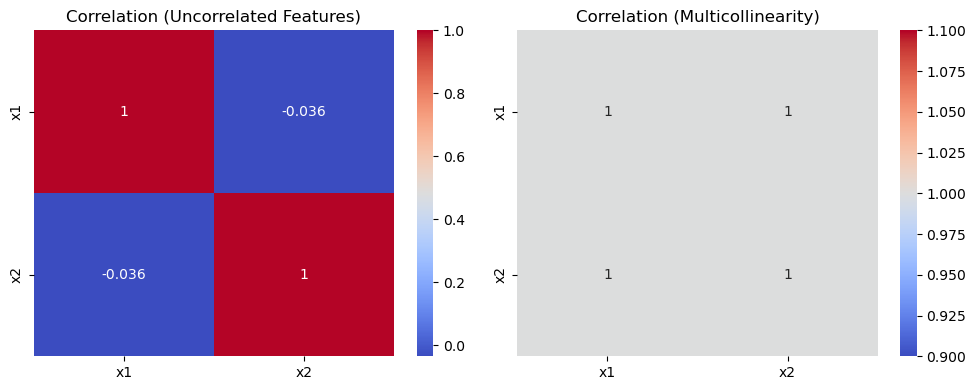


----- VIF: UNCORRELATED FEATURES -----
  Feature       VIF
0      x1  2.988253
1      x2  2.988253

----- VIF: CORRELATED FEATURES -----
  Feature  VIF
0      x1  inf
1      x2  inf


c:\Users\iyke\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



In [9]:
# Correlation Heatmaps

# Uncorrelated data (exclude intercept!)
df_uncorr = pd.DataFrame({
    "x1": x1,
    "x2": x2
})

# Correlated data
df_corr = pd.DataFrame({
    "x1": x1_c,
    "x2": x2_c
})

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(df_uncorr.corr(), annot=True, cmap="coolwarm", ax=axes[0])
axes[0].set_title("Correlation (Uncorrelated Features)")

sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation (Multicollinearity)")

plt.tight_layout()
plt.show()



# VIF (Variance Inflation Factor)
print("\n----- VIF: UNCORRELATED FEATURES -----")
X_uncorr_df = pd.DataFrame({
    "x1": x1,
    "x2": x2
})

vif_uncorr = pd.DataFrame()
vif_uncorr["Feature"] = X_uncorr_df.columns
vif_uncorr["VIF"] = [
    variance_inflation_factor(X_uncorr_df.values, i)
    for i in range(X_uncorr_df.shape[1])
]

print(vif_uncorr)


print("\n----- VIF: CORRELATED FEATURES -----")
X_corr_df = pd.DataFrame({
    "x1": x1_c,
    "x2": x2_c
})

vif_corr = pd.DataFrame()
vif_corr["Feature"] = X_corr_df.columns
vif_corr["VIF"] = [
    variance_inflation_factor(X_corr_df.values, i)
    for i in range(X_corr_df.shape[1])
]

print(vif_corr)

<a class="anchor" id="min"></a>
## 3. Core Minimization problem (Ordinary Least Squares)

### Model

In Multiple Linear Regression, the target variable $y$ is modeled as a linear combination of multiple features:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)} = \theta_0 + \theta_1 x_1^{(i)} + \ldots + \theta_p x_p^{(i)} + \varepsilon^{(i)}, \hspace{1 mm} i=1,\ldots,n \\ \Leftrightarrow
\underbrace{\begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix}}_{y} 
= \theta_0 \underbrace{\begin{pmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{pmatrix}}_{1_n} 
+ \theta_1 \underbrace{\begin{pmatrix} x_1^{(1)} \\ x_1^{(2)} \\ \vdots \\ x_1^{(n)} \end{pmatrix}}_{x_1}
+ \ldots 
+ \theta_p \underbrace{\begin{pmatrix} x_p^{(1)} \\ x_p^{(2)} \\ \vdots \\ x_p^{(n)} \end{pmatrix}}_{x_p}
+ \underbrace{\begin{pmatrix} \varepsilon^{(1)} \\ \varepsilon^{(2)} \\ \vdots \\ \varepsilon^{(n)} \end{pmatrix}}_{\varepsilon} 
\\ \Leftrightarrow
\begin{pmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(n)} \end{pmatrix}=
\underbrace{\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix}}_{X} 
\underbrace{\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix}}_{\theta} +
\begin{pmatrix} \varepsilon^{(1)} \\ \varepsilon^{(2)} \\ \vdots \\ \varepsilon^{(n)} \end{pmatrix}
\\ \Leftrightarrow
y = X \theta + \varepsilon
$$





Where
* $X \in \mathbb{R}^{n \times (p+1)}$ is Regression matrix
* $x_j^{(i)}$ is the $j$-th feature of observation $i$ $(j=1,\ldots,p)$
* $\theta_j$ is the corresponding parameter from the parameter vector $\theta \in \mathbb{R}^{p+1}$
* $\varepsilon^{(i)}$ is the error term capturing noise 
* $\color{yellow}\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)\color{white}$ for all $i=1,\ldots,n$ or more general $\varepsilon \sim \mathcal{N}(0,\sigma^2 \mathrm{I}_{n \times n})$


<h5 style="text-align:center;"><u>Two approaches to OLS</u></h5>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

### Predictions

The predicted value for observation $i$ is:

$$
\hat{y}^{(i)} = \hat{\theta}^\top x^{(i)} 
= \hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}
$$

where $\hat{\theta}=(\hat{\theta}_0, \hat{\theta}_1, \ldots, \hat{\theta}_p)^\top \in \mathbb{R}^{p+1}$ are the estimated parameters 

---

### Residuals

The residuals are the differences between the observed and predicted values

$$
\begin{align*}
\varepsilon^{(i)} 
&= y^{(i)}-\hat{y}^{(i)} \\
&= y^{(i)}-\hat{\theta}^\top x^{(i)} \\
&= y^{(i)}-(\hat{\theta}_0 + \hat{\theta}_1 x_1^{(i)} + \ldots + \hat{\theta}_p x_p^{(i)}) \\
&= y^{(i)}-\hat{\theta}_0 - \hat{\theta}_1 x_1^{(i)} - \ldots - \hat{\theta}_p x_p^{(i)} \\
\end{align*}
$$

and the vector of residuals is

$$
\varepsilon = y - X \hat{\theta}
$$

---

### Ordinary Least Squares (OLS)

Multiple linear Regression estimates the parameters $\theta$ by minimizing the sum of squared residuals $\text{SSE}$ / L2-loss:

$$
\begin{align*}
\hat{\theta} \in \arg \min_{\theta \in \mathbb{R}^{p+1}} \mathcal{R}_{\text{emp}}(\theta)
&=\arg \min_{\theta \in \mathbb{R}^{p+1}} \sum_{i=1}^n (y^{(i)}-\theta^\top x^{(i)} )^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y - X\theta \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta}  (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y  - 2\theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&=  - 2X^\top y + 2 X^\top X\theta 
\end{align*}
$$

Setting the derivative to 0 yields

$$
\begin{align*}
- 2X^\top y + 2 X^\top X\theta &= 0 \\ \Leftrightarrow
2 X^\top X\theta &= 2X^\top y \\ \Leftrightarrow
2 \frac{1}{2} X^\top X\theta &= 2\frac{1}{2}  X^\top y \\ \Leftrightarrow
X^\top X\theta &= X^\top y \\ \Leftrightarrow
(X^\top X)^{-1}X^\top X\theta &= (X^\top X)^{-1}X^\top y \\ \Leftrightarrow
\theta &= (X^\top X)^{-1} X^\top y 
\end{align*}
$$




</div> 


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

### Distributions and Likelihood

We assume $\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)$ and since $y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)}$ this means
$y^{(i)} \mid x^{(i)},\theta \sim \mathcal{N}(\theta^\top x^{(i)},\sigma^2)$. If we account for all data points at once then we look at $\varepsilon \sim \mathcal{N}(0,\sigma^2\mathrm{I}_{n \times n})$ and therefor $y \mid X,\theta \sim \mathcal{N}(X\theta,\sigma^2\mathrm{I}_{n \times n})$
The Probability Density function (PDF) of $y$ also called the Likelihood function is given by 

$$
\begin{align*}
p(y \mid X, \theta)
&=\frac{1}{(2\pi\sigma^2)^\frac{n}{2}} \exp \left({-\frac{1}{2\sigma^2}} (y-X\theta)^\top (y-X\theta)  \right)
\end{align*}
$$

Since we assume <span style="color: yellow;"><strong>Normality Errors</strong></span> $\color{yellow}(\varepsilon^{(i)} \sim \mathcal{N}(0,\sigma^2))$ and <span style="color: yellow;"><strong>Independent Errors</strong></span>, which in short is compactly called independent identically distributed, the Likelihood factorizes into

$$
\begin{align*}
p(y \mid X, \theta)
&= \prod_{i=1}^n p(y^{(i)} \mid x^{(i)},\theta) \\
&= \prod_{i=1}^n \frac{1}{(2\pi\sigma^2)^\frac{1}{2}} \exp \left({-\frac{(y^{(i)}-\theta^\top x^{(i)})^2}{2\sigma^2}}\right) \\
&= (2\pi\sigma^2)^\frac{-n}{2} \exp \left(\sum_{i=1}^n -\frac{(y^{(i)}-\theta^\top x^{(i)})^2}{2\sigma^2} \right)
\end{align*}
$$

---

### Log-Likelihood

Instead at looking at the likelihood consider the Log-Likelihood since this form allows easier computation

$$
\begin{align*}
\log p(y \mid X, \theta) 
&= -\frac{n}{2} \log (2\pi\sigma^2) + \sum_{i=1}^n -\frac{(y^{(i)}-\theta^\top x^{(i)})^2}{2\sigma^2} \\
&= -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y^{(i)}-\theta^\top x^{(i)})^2 \\
&= -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta) \\
\end{align*}
$$

---

### Maximum (log) likelihood estimation (MLE)

$$
\begin{align*}
\hat{\theta} \in \arg \max_{\theta \in \mathbb{R}^{p+1}} \log p(y \mid X, \theta) 
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} (y-X\theta)^\top(y-X\theta) \\
&= \frac{\partial}{\partial \theta}  (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y  - 2\theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&=  - 2X^\top y + 2 X^\top X\theta 

\end{align*}
$$

Setting the derivative to 0 yields

$$
\begin{align*}
- 2X^\top y + 2 X^\top X\theta &= 0 \\ \Leftrightarrow
2 X^\top X\theta &= 2X^\top y \\ \Leftrightarrow
X^\top X\theta &= X^\top y \\ \Leftrightarrow
(X^\top X)^{-1}X^\top X\theta &= (X^\top X)^{-1}X^\top y \\ \Leftrightarrow
\theta &= (X^\top X)^{-1} X^\top y 
\end{align*}
$$



</div>

</div> 

### OLS Solution

Solving the minimization yields the parameter estimates:

$$
\hat{\theta} = (X^\top X)^{-1} X^\top y 
$$

or explicitly:

$$
\begin{pmatrix}
\hat{\theta}_0 \\
\hat{\theta}_1 \\
\vdots \\
\hat{\theta}_p \\
\end{pmatrix} 
= (X^\top X)^{-1} X^\top
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)} \\
\end{pmatrix}  
$$

* Each $\hat{\theta}_j$ measures the effect of feature $x_j$ on the target, controlling for all other features
* $\hat{\theta}_0$ is the intercept (baseline prediction when all features are zero)



&#128161; Interpretation

- The OLS solution finds the hyperplane in $p$-dimensional feature space that minimizes the squared distance (residuals) to the observed target values

- Each feature's coefficient represents its marginal effect on the target, holding other features constant

- This extends the simple linear regression case to multiple correlated or uncorrelated predictors

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression() # model is now a LinearRegression object
model = LinearRegression(fit_intercept=False) # model is a LinearRegression object where the Regression matrix has no intercept column

model.fit(X, y) # X of shape (number_observations,number_features) and y of shape (number_observations,) and model is now a a fitted LinearRegression object

model.n_features_in_ # Number of features
model.coef_ # get estimated slopes beta_1_hat,...,beta_p_hat of shape (n_features_in_,) as numpy.ndarray
model.intercept_ # get estimated intercept beta_0_hat
model.feature_names_in_ # Feature names (if using pandas)
model.rank_ # Rank of X matrix
model.singular_ # Singular values
model.predict(X_new) # Predict new values
model.score(X, y) # R^2 score (more on this later)
model.get_params() # Get parameters
# {
#  'copy_X': True,
#  'fit_intercept': True,
#  'n_jobs': None,
#  'positive': False,
#  'tol': 1e-06
# }

```

##### Bonus: Plotting 3D data for Multiple linear Regressioon (2 features)

```python
import plotly.graph_objects as go
import plotly.express as px

# Prep data
x1 = X[:, 1]
x2 = X[:, 2]
y = y

# Fit model
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

# Create grid (many combinations of x1 and x2 arranged in a 2D grid)
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)


# Build grid design matrix over grid (same cnumber of columns as X but more rows meaning more synthetic data points)
grid_X = np.column_stack((
    np.ones(grid_x1.size),
    grid_x1.ravel(),
    grid_x2.ravel()
))

# Predict values on the grid
surface = (grid_X @ beta_hat).reshape(grid_x1.shape)


# Plot the original data
fig = px.scatter_3d(x=x1, y=x2, z=y,
    title="Fitted Plane",
    labels={'x':'Feature1','y':'Feature2','z':'Target'}
)


# Add the regression plane
fig.add_trace(go.Surface(
    x=grid_x1,
    y=grid_x2,
    z=surface,
    opacity=0.5
))

fig.show()

```

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
# Generate data
np.random.seed(1901) # for reproducibility of random numbers

def truncate(x, decimals=2): # turns numbers like 7.4300e+02 into 743.0
    factor = 10**decimals
    return int(x * factor) / factor


def generate_realistic_bank_data(n):
    X = np.column_stack((np.ones(n), np.zeros((n, 2))))
    y = np.zeros(n)

    for i in range(n):
        # Slightly narrower and more realistic ranges
        income = np.random.uniform(20000, 80000)
        
        # Rating depends on income but with less noise
        rating = 300 + 0.005 * income + np.random.normal(0, 30)

        # TRUE linear relationship (balanced coefficients)
        balance = (
            500 +                 # intercept (shift upward)
            2.0 * rating +        # moderate effect
            0.05 * income +       # smaller effect than before
            np.random.normal(0, 300)  # noise (visible but not overwhelming)
        )

        X[i, 1] = rating
        X[i, 2] = income
        y[i] = balance

    return X, y


#help(np.clip)
n = 100 # number observations
X, y = generate_realistic_bank_data(n)


# Extract features for plotting
x1 = X[:, 1] # feature 1
x2 = X[:, 2] # feature 2

# Fit model (OLS)
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

# model with sklearn
model = LinearRegression().fit(X, y)

print(f"Compare estimates: beta_hat=({beta_hat[0]:.2f},{beta_hat[1]:.2f},{beta_hat[2]:.2f}) and sklearn beta_hat=({model.intercept_:.2f},{model.coef_[1]:.2f},{model.coef_[2]:.2f})")

# Predictions for data points
y_pred = X @ beta_hat


# Build the design matrix for the grid
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

grid_X = np.column_stack((
    np.ones(grid_x1.size),
    grid_x1.ravel(),
    grid_x2.ravel()
))

# Predict plane values
surface_pred = (grid_X @ beta_hat).reshape(grid_x1.shape)


# Plot
fig = px.scatter_3d(
    x=x1, y=x2, z=y,
    title="Fitted Plane",
    labels={'x': 'Rating', 'y': 'Income', 'z': 'Balance'}
)

# Add regression plane
fig.add_trace(go.Surface(
    x=grid_x1,
    y=grid_x2,
    z=surface_pred,
    opacity=0.5,
    showscale=False,
    name="Fitted Plane"
))

fig.update_layout(width=800, height=600)
fig.show()

Compare estimates: beta_hat=(717.38,1.74,0.05) and sklearn beta_hat=(717.38,1.74,0.05)


In [12]:
# Effect of rating (income fixed)

def predict_balance(rating, income):
    return beta_hat[0] + beta_hat[1] * rating + beta_hat[2] * income


# Keep income FIXED
income = 50000

rating_1 = 600
rating_2 = 620   # increase by 20

balance_1 = predict_balance(rating_1, income)
balance_2 = predict_balance(rating_2, income)

print("--- Effect of rating (holding income constant) ---")
print(f"Income is fixed at: {income}")
print(f"Rating increases from {rating_1} to {rating_2} (+20)")

print(f"Balance before: {balance_1}")
print(f"Balance after:  {balance_2}")

print(f"Change in balance: {balance_2 - balance_1}")
print(f"Expected change: {beta_hat[1]} * 20 = {balance_2 - balance_1}")

# Key idea:
print("Only rating changed -> effect comes ONLY from beta_rating")

#---------------------------------------------------------------

# Effect of income (rating fixed)
rating = 600

income_1 = 40000
income_2 = 55000   # increase by 15,000

balance_1 = predict_balance(rating, income_1)
balance_2 = predict_balance(rating, income_2)

print("\n--- Effect of income (holding rating constant) ---")
print(f"Rating is fixed at: {rating}")
print(f"Income increases from {income_1} to {income_2} (+15000)")

print(f"Balance before: {balance_1}")
print(f"Balance after:  {balance_2}")

print(f"Change in balance: {balance_2 - balance_1}")
print(f"Expected change: {beta_hat[2]} * 15000 = {balance_2 - balance_1}")

# Key idea:
print("Only income changed -> effect comes ONLY from beta_income")

--- Effect of rating (holding income constant) ---
Income is fixed at: 50000
Rating increases from 600 to 620 (+20)
Balance before: 4165.543929522558
Balance after:  4200.327068227807
Change in balance: 34.78313870524926
Expected change: 1.7391569352624447 * 20 = 34.78313870524926
Only rating changed -> effect comes ONLY from beta_rating

--- Effect of income (holding rating constant) ---
Rating is fixed at: 600
Income increases from 40000 to 55000 (+15000)
Balance before: 3684.6102408838146
Balance after:  4406.010773841929
Change in balance: 721.4005329581146
Expected change: 0.04809336886387429 * 15000 = 721.4005329581146
Only income changed -> effect comes ONLY from beta_income


### L1 loss vs L2 loss


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
border:2px solid white;
width:50%;
">


<h5 style="text-align:center;">L1 loss</h5>

$$
\sum_{i=1}^n \mid y_i - \hat{y}_i \mid
$$

**Motivation:** 🛡️ Robust to outliers
* Penalizes absolute value $\mid r \mid$ of residuals $r=y_i - \hat{y}_i$
* Errors grow linearly, not quadratically
* Example:
    - error = 10 $\rightarrow$ loss = 10

&#128073; Outliers don't dominate the model

&#128202; **Matches Laplace noise**

If errors follow:

$$
\varepsilon_i \sim \text{Laplace}(0, b)
$$

⚙️ **Math**
* Not differentiable at $r=0$
* Optimal parameters are computed numerically (e.g. Linear programming,Convex optimization)

&#10071; **Disadvantage:** No simple closed-form like OLS
</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
border:2px solid white;
width:50%;
">

<h5 style="text-align:center;">L2 loss</h5>

$$
\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

**Motivation:** &#128300; Strongly penalize large errors 
* Penalizes quadratic value $r^2$ of residuals $r=y_i - \hat{y}_i$
* Squaring makes big errors much more expensive
* Example:
    - error = 2 $\rightarrow$ loss = 4
    - error = 10 $\rightarrow$ loss = 100 (not 10)

&#128073; So the model tries hard to avoid large mistake

&#128202; **Matches Gaussian noise**

If errors follow:

$$
\varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

⚙️ **Math**
* Smooth and differentiable everywhere
* Optimal parameters can be computed analytically via OLS or numerically (e.g. Gradient descent)

&#10071; **Disadvantage:** Sensitive to outliers
</div>

</div>

🧠 **Key insight**

- L2 loss = Maximum Likelihood under Gaussian noise  
- L1 loss = Maximum Likelihood under Laplace noise

In [13]:
# Generate data
np.random.seed(1432) # for reproducibility
n = 25 # sample size

x1 = np.sort(np.random.randint(75, 250, n)) # feature 1
x2 = np.sort(np.random.uniform(0, 100, n)) # feature 2

X = np.column_stack((np.ones(n), x1, x2)) # design matrix

true_beta = np.array([0.3, 4.9, 7]) # true beta
error = np.random.normal(0, 200, n) # error

y = X @ true_beta + error # target


def fit_models(X, y):
    # L2 (closed form)
    beta_l2 = np.linalg.inv(X.T @ X) @ X.T @ y

    # L1 (grid search, SMALL grid)
    b0_vals = np.linspace(-50, 50, 20)
    b1_vals = np.linspace(3, 6, 20)
    b2_vals = np.linspace(5, 9, 20)

    best_loss = np.inf
    beta_l1 = None

    for b0 in b0_vals:
        for b1 in b1_vals:
            for b2 in b2_vals:
                y_pred = b0 + b1 * X[:,1] + b2 * X[:,2]
                loss = np.sum(np.abs(y - y_pred))
                if loss < best_loss:
                    best_loss = loss
                    beta_l1 = np.array([b0, b1, b2])

    return beta_l2, beta_l1


# BEFORE outlier
beta_l2, beta_l1 = fit_models(X, y)

print("Before outlier")
print("True beta:", true_beta)
print("L2 beta:", beta_l2)
print("L1 beta:", beta_l1, "\n")


# Add outlier
#X = np.vstack((X[0:-1,:],np.array([1,3.8]))) # replace last observation with outlier
#y = X @ true_beta + error
#X = np.vstack((X,np.array([1,3.8])))
#y=np.hstack((y,1))
x1_out = np.append(x1, 200)
x2_out = np.append(x2, 90)
y_out = np.append(y, 4000)

X_out = np.column_stack((np.ones(len(x1_out)), x1_out, x2_out))

beta_l2_out, beta_l1_out = fit_models(X_out, y_out)

print("After outlier")
print("L2 beta:", beta_l2_out)
print("L1 beta:", beta_l1_out)


def plot_3d_planes(X, y, beta_l2, beta_l1, title="Regression Planes"):
    """
    X: design matrix (with intercept)
    y: target
    beta_l2: coefficients from L2 (OLS)
    beta_l1: coefficients from L1 (grid search)
    """
    x1 = X[:,1]
    x2 = X[:,2]

    # Create grid
    grid_x1, grid_x2 = np.meshgrid(
        np.linspace(x1.min(), x1.max(), 30),
        np.linspace(x2.min(), x2.max(), 30)
    )
    grid_X = np.column_stack((np.ones(grid_x1.size), grid_x1.ravel(), grid_x2.ravel()))

    # Predict planes
    surface_l2 = (grid_X @ beta_l2).reshape(grid_x1.shape)
    surface_l1 = (grid_X @ beta_l1).reshape(grid_x1.shape)

    # Scatter plot
    fig = px.scatter_3d(x=x1, y=x2, z=y, labels={'x':'Feature1','y':'Feature2','z':'Target'})
    
    # Add L2 plane
    fig.add_trace(go.Surface(
        x=grid_x1, y=grid_x2, z=surface_l2,
        opacity=0.5,colorscale=[[0, 'red'], [1, 'red']],
        showlegend=True,
        showscale=False,
        name="L2 Plane"
    ))
    # Add L1 plane
    fig.add_trace(go.Surface(
        x=grid_x1, y=grid_x2, z=surface_l1,
        opacity=0.5, colorscale='Blues',
        showlegend=True,
        showscale=False,
        name="L1 Plane"
    ))

    fig.update_layout(title=title, width=800, height=600)
    fig.show()


# Plot before outlier
plot_3d_planes(X, y, beta_l2, beta_l1, title="L1 vs L2 Planes (Before Outlier)")

# Plot after outlier 
plot_3d_planes(X_out, y_out, beta_l2_out, beta_l1_out, title="L1 vs L2 Planes (After Outlier)")

Before outlier
True beta: [0.3 4.9 7. ]
L2 beta: [-181.77524963    6.29372201    5.1213596 ]
L1 beta: [-44.73684211   5.36842105   7.10526316] 

After outlier
L2 beta: [779.25147482  -3.72177299  23.9316568 ]
L1 beta: [-39.47368421   5.21052632   7.52631579]


<a class="anchor" id="quality"></a>
## 4. Model Quality

In Multiple Linear Regression, the model parameters $\hat{\theta}$ are estimated by minimizing the **Sum of Squared Errors (SSE)**, which measures the squared deviation between observed and predicted values.

---

### Sum of Squared Errors (SSE)

The SSE is defined as:

$$
SSE = \sum_{i=1}^n \left(\varepsilon^{(i)}\right)^2 
= \sum_{i=1}^{n}\left(y^{(i)} - \hat{y}^{(i)}\right)^2
$$

or in matrix form:

$$
SSE = \lVert y - \hat{y} \rVert_2^2 = \lVert y - X\hat{\theta} \rVert_2^2
$$

---

### Total Sum of Squares (SST)

The **Total Sum of Squares (SST)** measures the total variability of the target variable around its mean:

$$
SST = \sum_{i=1}^{n}\left(y^{(i)} - \bar{y}\right)^2
$$

where:

$$
\bar{y} = \frac{1}{n} \sum_{i=1}^n y^{(i)}
$$

---

### Regression Sum of Squares (SSR)

The **Regression Sum of Squares (SSR)** measures the variability explained by the model:

$$
SSR = \sum_{i=1}^{n}\left(\hat{y}^{(i)} - \bar{y}\right)^2
$$

---

### Decomposition of Variance

These quantities satisfy the fundamental decomposition:

$$
SST = SSE + SSR
$$

or equivalently:

$$
\sum_{i=1}^{n}(y^{(i)} - \bar{y})^2
=
\sum_{i=1}^{n}(y^{(i)} - \hat{y}^{(i)})^2
+
\sum_{i=1}^{n}(\hat{y}^{(i)} - \bar{y})^2
$$

---

### Coefficient of Determination ($R^2$)

A common measure of model quality is the **coefficient of determination**:

$$
R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}
$$

It represents the proportion of total variance in the target variable that is explained by the model.

---

### Interpretation

- $R^2 = 1$: Perfect fit (all data points lie on the regression hyperplane)  
- $R^2 = 0$: The model explains no variability beyond the mean  
- $0 < R^2 < 1$: Partial explanatory power  

---

### &#128161; Notes

- $R^2$ is invariant to the number of predictors, but **can increase** when adding irrelevant features  
- For multiple regression, it is often useful to consider the **adjusted $R^2$**, which penalizes model complexity  

---

### Adjusted $R^2$

To account for the number of predictors $p$, the adjusted $R^2$ is defined as:

$$
R^2_{\text{adj}} = 1 - \frac{SSE/(n - p - 1)}{SST/(n - 1)} = 1 - \frac{n-1}{n-(p+1)}(1-R^2)
$$

This happens because OLS:


$$\text{Minimizes squared error → adding variables can only improve (or keep same) fit}$$

So:

$$
R^2 \uparrow \text{(always non-decreasing)}
$$

However

$$
R^2_{\text{adj}} \downarrow \text{(decreasing with irrelevant features or stays the same)}
$$

```python
import statsmodels.api as sm
X_sm = sm.add_constant(np.column_stack((feature1, feature2))) # add intercept column

model_sm = sm.OLS(y, X_sm).fit() # fit model

model_sm.rsquared # get model score
model_sm.rsquared_adj # get adjusted model score

```

In [14]:
# Generate data
np.random.seed(1650) # for reproducibility
n = 100 # sample size
x1 = np.sort(np.random.randint(75, 250, n)) # feature 1
x2 = np.sort(np.random.uniform(0, 100, n)) # feature 2
X = np.column_stack((np.ones(n), x1, x2)) # design matrix
true_beta = np.array([0.3, 4.9, 7])
error = np.random.normal(0, 200, n)
y = X @ true_beta + error # target

# Fit model manually and with sklearn
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
model = LinearRegression().fit(X,y)
print(f"beta_hat={np.round(beta_hat,3)}")
print(f"sklearn beta_hat={np.round([model.intercept_,model.coef_[1],model.coef_[2]],3)}\n")

# Predictions and Residuals
y_hat = X @ beta_hat
y_mean = np.mean(y)
SSR = np.sum((y_hat - y_mean)**2)
SST = np.sum((y-y_mean)**2)
R2 = SSR / SST
print(f"R2={R2:.4f}")
print(f"sklearn R2={model.score(X,y):.4f}")

x3 = np.random.normal(0, 5, n) # Add useless third feature (pure noise)

X_aug = np.column_stack((np.ones(n), x1, x2, x3)) # New design matrix with useless feature

# Fit augmented model
beta_hat_aug = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y
model_aug = LinearRegression().fit(X_aug, y)

# Predictions
y_hat_aug = X_aug @ beta_hat_aug

# R²
SSR_aug = np.sum((y_hat_aug - y_mean)**2)
R2_aug = SSR_aug / SST

print("\nWith useless feature R2 will increase slightly, even though the feature is pure noise and has no real predictive power")
print(f"R2={R2_aug:.4f}")
print(f"sklearn R2={model_aug.score(X_aug, y):.4f}")

beta_hat=[-20.642   4.715   7.872]
sklearn beta_hat=[-20.642   4.715   7.872]

R2=0.8870
sklearn R2=0.8870

With useless feature R2 will increase slightly, even though the feature is pure noise and has no real predictive power
R2=0.8874
sklearn R2=0.8874


In [15]:
X_sm = sm.add_constant(np.column_stack((x1, x2)))
model_sm = sm.OLS(y, X_sm).fit()

# Number of observations
n = len(y)

# Original model (2 predictors: x1, x2)
p = 2
R2_adj = 1 - ((n - 1) / (n - p - 1)) * (1 - R2)

# Augmented model (3 predictors: x1, x2, x3)
p_aug = 3
R2_adj_aug = 1 - ((n - 1) / (n - p_aug - 1)) * (1 - R2_aug)

print("\n---- Adjusted R2 comparison ----")
print(f"Original R2:{R2:.4f}")
print(f"Original Adj R2 (manually):{R2_adj:.4f} and with sklearn {model_sm.rsquared_adj:.4f}")

X_sm = sm.add_constant(np.column_stack((x1, x2, x3)))
model_sm = sm.OLS(y, X_sm).fit()

print(f"\nWith useless feature R2: {R2_aug:.4f}")
print(f"With useless feature Adj R2: {R2_adj_aug:.4f} and with sklearn {model_sm.rsquared_adj:.4f}")


---- Adjusted R2 comparison ----
Original R2:0.8870
Original Adj R2 (manually):0.8846 and with sklearn 0.8846

With useless feature R2: 0.8874
With useless feature Adj R2: 0.8839 and with sklearn 0.8839


### VIF (Variance Inflation Factor)

$$
\mathrm{VIF}_j = \frac{1}{1-\mathrm{R}_j^2}
$$

$$
\mathrm{R}_j^2 = \frac{\text{SSR}_j}{\text{SST}_j} = 1 - \frac{\text{SSE}_j}{\text{SST}_j}
$$

$$
\underbrace{\text{SST}_j = \sum_{i=1}^n (x_{ji} - \bar{x}_j)^2}_{\text{total variation of }x_j}
\hspace{1 mm} \mid \hspace{1 mm} 
\underbrace{\text{SSR}_j = \sum_{i=1}^n (\hat{x}_{ji} - \bar{x}_j)^2}_{\text{variation explained by regressing } x_j​ \text{ on other predictors}}
\hspace{1 mm} \mid \hspace{1 mm} 
\underbrace{\text{SSE}_j = \sum_{i=1}^n (x_{ji} - \hat{x}_{ji})^2}_{\text{residual variation}}
$$

- $i=1,...,n$
- $\mathrm{VIF}_j \approx$ 1 means predictor $x_j$ is not correlated to the other predictors
- 1 < $\mathrm{VIF}_j$ < 5 means predictor $x_j$ is moderately correlated to the other predictors
- $\mathrm{VIF}_j$ > 5 means predictor $x_j$ is potentially strongly correlated to the other predictors
- $\mathrm{VIF}_j$ > 10 means predictor $x_j$ is seriously correlated to the other predictors
- $\mathrm{VIF}_j \rightarrow \infty$ means predictor $x_j$ is perfectly correlated to the other predictors (because $\mathrm{R}_j^2=1$)


```python
from statsmodels.stats.outliers_influence import variance_inflation_factor

variance_inflation_factor(X_features, j) # takes matrix X_features (without intercept) and computes VIF for feature x_j

```

In [16]:
def compute_vif(X):
    """ 
    Compute VIF from scratch. X: numpy array (without intercept!) 
    """
    n_features = X.shape[1]
    vif_values = []

    for j in range(n_features):
        y_j = X[:, j] # target variable is one of the features
        X_others = np.delete(X, j, axis=1) # delete feature picked as target

        X_others = np.column_stack([np.ones(X_others.shape[0]), X_others]) # create design matrix

        # Ordinary OLS
        beta_hat = np.linalg.inv(X_others.T @ X_others) @ X_others.T @ y_j
        # More stable OLS
        #beta_hat = np.linalg.pinv(X_others.T @ X_others) @ X_others.T @ y_j
        # Best OLS
        #beta_hat = np.linalg.lstsq(X_others, y_j, rcond=None)[0] # avoids crashes if matrix is nearly singular due to high multicollinearity

        # # Predicted values
        y_hat = X_others @ beta_hat

        # Compute R^2
        ss_res = np.sum((y_j - y_hat)**2)
        ss_tot = np.sum((y_j - np.mean(y_j))**2)
        R2 = 1 - ss_res / ss_tot

        # Compute VIF
        #vif = 1 / (1 - R2) # does not handle divison by 0
        vif = np.inf if np.isclose(1 - R2, 0) else 1 / (1 - R2) # more stable handles division by 0 
        vif_values.append(vif)

    return vif_values

In [17]:
# Generate data
np.random.seed(1732) # for reproducibility
n = 50 # sample size
x1 = np.sort(np.random.randint(60, 250, n)) # feature 1
x2 = np.sort(np.random.uniform(20, 100, n)) # feature 2
X = np.column_stack((np.ones(n), x1, x2)) # design matrix
true_beta = np.random.uniform(0,5,3)
error = np.random.normal(0, 200, n)
y = X @ true_beta + error # target

# Fit model manually and with sklearn
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
model = LinearRegression().fit(X,y)
print(f"beta_hat={np.round(beta_hat,3)}")
print(f"sklearn beta_hat={np.round([model.intercept_,model.coef_[1],model.coef_[2]],3)}\n")

# Prepare data for VIF
# X currently has intercept as first column -> remove it
X_features = X[:, 1:] # only x1 and x2

# Compute VIF using your function
vif_custom = compute_vif(X_features)

# Compute VIF using statsmodels
vif_statsmodels = [variance_inflation_factor(X_features, i) for i in range(X_features.shape[1])]

# Compare results
print("VIF comparison:")
for i, (v_custom, v_lib) in enumerate(zip(vif_custom, vif_statsmodels), start=1):
    print(f"x{i}: custom={v_custom:.4f}, statsmodels={v_lib:.4f}")

beta_hat=[73.238  7.762 -6.387]
sklearn beta_hat=[73.238  7.762 -6.387]

VIF comparison:
x1: custom=41.7019, statsmodels=405.1730
x2: custom=41.7019, statsmodels=405.1730


<a class="anchor" id="stats"></a>
## 5. Statistical Inference

In Multiple Linear Regression, statistical inference allows us to quantify the uncertainty of the estimated parameters $\hat{\theta}$ and to test hypotheses about the relationship between predictors and the target variable.

---

### Distribution of the OLS Estimator

Assume the classical linear model:

$$
y = X\theta + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_n)
$$

with $X \in \mathbb{R}^{n \times (p+1)}$. The OLS estimator is:

$$
\hat{\theta} = (X^\top X)^{-1} X^\top y
$$



### Mean of $\hat{\theta}$

$$
\begin{align*}
\mathbb{E}(\hat{\theta}) 
&= \mathbb{E}\left((X^\top X)^{-1} X^\top y \right) \\
&= (X^\top X)^{-1} X^\top \mathbb{E}[y] \\
&= (X^\top X)^{-1} X^\top (X\theta) \\
&= (X^\top X)^{-1} X^\top X\theta \hspace{1 mm} \mid \hspace{1 mm} (X^\top X)^{-1} X^\top X = \mathrm{I} \\
&= \theta
\end{align*}
$$

$\Rightarrow$ The estimator is **unbiased**.



### Variance of $\hat{\theta}$

$$
\begin{align*}
\mathrm{Var}(\hat{\theta})
&= \mathrm{Var}\left((X^\top X)^{-1} X^\top y \right) \hspace{1 mm} \mid \hspace{1 mm} \mathrm{Var}(Ay) = A \mathrm{Var}(y) A^\top \\
&= (X^\top X)^{-1} X^\top \mathrm{Var}(y) ((X^\top X)^{-1} X^\top)^\top \\
&= (X^\top X)^{-1} X^\top \mathrm{Var}(y) X ((X^\top X)^{-1})^\top \hspace{1 mm} \mid \hspace{1 mm} ((X^\top X)^{-1})^\top = (X^\top X)^{-1} \\
&= (X^\top X)^{-1} X^\top \mathrm{Var}(y) X (X^\top X)^{-1} \\
&= (X^\top X)^{-1} X^\top (\sigma^2 I_n) X (X^\top X)^{-1} \\
&= \sigma^2 (X^\top X)^{-1} X^\top X (X^\top X)^{-1} \hspace{1 mm} \mid \hspace{1 mm} X^\top X (X^\top X)^{-1} = \mathrm{I} \\
&= \sigma^2 (X^\top X)^{-1} \mathrm{I} \\
&= \sigma^2 (X^\top X)^{-1} \\
\end{align*}
$$



### Distribution

$$
\hat{\theta} \sim \mathcal{N}\left(\theta, \sigma^2 (X^\top X)^{-1} \right)
$$

and standardized we have

$$
\frac{\hat{\theta}-\theta}{\sigma \sqrt{(X^\top X)^{-1}}} \sim \mathcal{N}\left(0, 1 \right)
$$



### Estimation of $\sigma^2$

Since $\sigma^2$ is unknown, it is estimated using $\hat{\sigma}^2$ which is why the standardization now follows the $t$-distribution:

$$
\hat{\sigma}^2 = \frac{1}{n - (p + 1)} \lVert y - X\hat{\theta} \rVert_2^2
$$



## $t$-Test for a Single Coefficient

We test:

$$
H_0: \theta_j = 0 \quad \text{vs.} \quad H_1: \theta_j \neq 0
$$

The test statistic is:

$$
t = \frac{\hat{\theta}_j - 0}{\hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}}
$$

Under $H_0$:

$$
t \sim t_{n - (p+1)}
$$



### Confidence Interval

A $(1-\alpha) \cdot 100 \%$ confidence interval for $\theta_j$ is:


$$
\left[\hat{\theta}_j - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}},\hspace{1 mm} \hat{\theta}_j + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}} \right]
$$



### Derivation from t-Statistic

Starting from:

$$
\begin{align*}
 - t_{n-p-1,\,1-\alpha/2} 
&\leq 
\frac{\hat{\theta}_j - \theta_j}{\hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}}
\leq 
t_{n-p-1,\,1-\alpha/2}  \\ \Leftrightarrow

 - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}
&\leq 
\hat{\theta}_j - \theta_j
\leq 
t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}} \\ \Leftrightarrow

- \hat{\theta}_j - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}
&\leq 
- \theta_j
\leq 
- \hat{\theta}_j + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}} \\ \Leftrightarrow

\hat{\theta}_j + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}
&\geq 
\theta_j
\geq 
\hat{\theta}_j - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}} \\ \Leftrightarrow

\hat{\theta}_j - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}
&\leq 
\theta_j
\leq 
\hat{\theta}_j + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{(X^\top X)^{-1}_{jj}}

\end{align*}
$$

This is the confidence interval above.

---

## Confidence Interval for Mean Response $\mathbb{E}(y_0 | x_0)$

For some data point $x_0 \in \mathbb{R}^{p+1}$ the response is:

$$
y_0 = x_0^\top \theta + \varepsilon_0
$$

**$x_0$ could be one of your observed data points, or a new point.**

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Mean of Prediction

$$
\begin{align*}
\mathbb{E}(y_0)
&= \mathbb{E}(x_0^\top \theta + \varepsilon_0) \\
&= \mathbb{E}(x_0^\top \theta) + \mathbb{E}(\varepsilon_0) \\
&= x_0^\top \theta \\
\end{align*}
$$

Estimate $\theta$ using $\hat{\theta}$ to get $\hat{y}_0 = x_0^\top \hat{\theta}$


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

### Variance of Prediction

$$
\begin{align*}
\mathrm{Var}(\hat{y}_0)
&= \mathrm{Var}(x_0^\top \hat{\theta}) \\
&= x_0^\top \mathrm{Var}(\hat{\theta}) (x_0^\top)^\top \\
&= x_0^\top \sigma^2 (X^\top X)^{-1} x_0 \\
&= \sigma^2 x_0^\top (X^\top X)^{-1} x_0 \\
\end{align*}
$$

Estimate $\sigma$ using $\hat{\sigma}$, which results in $\hat{y}_0$ being $t$-distributed. 

</div>
</div>

### Confidence Interval (CI) for $\mathbb{E}(y_0)$

The confidence interval only accounts for uncertainty in estimating the mean:

$$
\left[\hat{y}_0 - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{x_0^\top (X^\top X)^{-1} x_0}, \hspace{1 mm} 
\hat{y}_0 + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{x_0^\top (X^\top X)^{-1} x_0} \right]
$$



## Confidence Interval for New Response $y_0$ (also called Prediction Interval)

For a new observation $x_0 \in \mathbb{R}^{p+1}$ we predict:

$$
\hat{y}_0 = x_0^\top \hat{\theta}
$$

**$x_0$ is always treated as a new data point (even if it matches an existing one).**

### Variance of Prediction

$$
\begin{align*}
\mathrm{Var}(y_0 - \hat{y}_0)
&= \mathrm{Var}(y_0) + \mathrm{Var}(\hat{y}_0) \\
&= \mathrm{Var}(x_0^\top \theta + \varepsilon_0) + \mathrm{Var}(x_0^\top \hat{\theta}) \\
&= \mathrm{Var}(\varepsilon_0) + x_0^\top \mathrm{Var}(\hat{\theta}) (x_0^\top)^\top \\
&= \sigma^2  + x_0^\top \mathrm{Var}(\hat{\theta}) (x_0^\top)^\top \\
&= \sigma^2  + x_0^\top \sigma^2 (X^\top X)^{-1} x_0 \\
&= \sigma^2 \left(1 +  x_0^\top (X^\top X)^{-1} x_0 \right) \\

\end{align*}
$$

- Notice the extra 1 inside the square root for the prediction interval. That is the contribution of the observation noise $\varepsilon_0$.


### Prediction Interval (PI)

The prediction interval accounts for both the uncertainty in estimating the mean and the intrinsic variability (noise) of new observations:


$$
\left[\hat{y}_0 - t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{1 + x_0^\top (X^\top X)^{-1} x_0}, \hspace{1 mm} 
\hat{y}_0 + t_{n-p-1,\,1-\alpha/2} \cdot \hat{\sigma} \sqrt{1 + x_0^\top (X^\top X)^{-1} x_0} \right]
$$

<p align="center">
<img src="CI_PI_.jpg" width="600"/>
</p>


**Confidence Interval (CI):**
- Imagine you could repeatedly sample your dataset from the population and fit a regression line each time with different $\hat{\theta}$ as estimates for the true unknown $\theta$.
- For a fixed $x_0$, each line gives a slightly different predicted $\hat{y}_0$.
- The CI tells you where the mean of all those predicted $\hat{y}_0$ values would fall.
- More precisely CI quantifies how much our estimated line could vary if we repeated the study.
- Visually: draw a narrow band around the regression line $-$ it shows uncertainty in the line itself, not individual points.
- We ask: "Where is the average height of people with age 30 likely to be?"
- CI answers: "I am $(1-\alpha) \cdot 100\%$ confident that the true mean value of $y=\text{height}$ at $x_0 = 30$ years lies in this range."
- Limits: CI only reflects uncertainty in estimating the regression line (i.e. $\hat{\theta}$), not the variability of new observations.
- CI $\rightarrow$ Where is the average response likely to be at $x_0$?" $\rightarrow$ narrow band around regression line.


**Prediction Interval (PI):**
- Now, for a fixed $x_0$, we also consider the random variability of a new single observation $y_0$.
- This includes the CI uncertainty plus the extra noise in a new observation.
- PI accounts for both the uncertainty in  $\hat{\theta}$ and the intrinsic noise $\varepsilon_0$ of that new observation. 
- Visually: draw a wider band around the line $-$ it covers where new data points are likely to appear.
- We asks: "Where is the height of a random 30-year-old person likely to be?"
- PI answers: "I am $(1-\alpha) \cdot 100\%$ confident that the new $y=\text{height}$ at $x_0 = 30$ years falls within this range"
- PI $\rightarrow$ "Where is a single new observation likely to fall at $x_0$?" $\rightarrow$ wider band, because individual points scatter around the regression line.

&#129504; **Even if our regression line looks perfect, $\hat{\theta}$ is still an estimate, so CI captures the uncertainty in the line itself. PI adds the uncertainty from new individual outcomes.**

&#9989; **CI is about the variability of the mean prediction across many possible regression lines whereas PI is about variability of a new data point around the line, and hence it’s always wider.**



---

### F-Test (Overall Model Significance)

We test:

$$
H_0: \theta_1 = \theta_2 = \ldots = \theta_p = 0 \hspace{1 mm} \text{ vs. } \hspace{1 mm} H_1: \text{At least one } \theta_j \neq 0
$$





### Test Statistic

$$
F = \frac{SSR / p}{SSE / (n - p - 1)}
$$

Under $H_0$:

$$
F \sim F_{p,\, n - p - 1}
$$



### Interpretation

- Large $F$ $\Rightarrow$ model explains significant variance  
- Small $F$ $\Rightarrow$ predictors have little explanatory power  



<!--### Alternative Form-->

<!--%Using $R^2$:-->

<!--$$F = \frac{R^2 / p}{(1 - R^2)/(n - p - 1)}$$-->


---

### &#128161; Summary

- $\hat{\theta}$ is unbiased and normally distributed  
- Variance depends on $(X^\top X)^{-1}$ (multicollinearity effect!)  
- t-tests assess individual coefficients  
- F-test assesses overall model significance  
- Confidence and prediction intervals quantify uncertainty  



```python
import statsmodels.api as sm # for Statistical Inference

X = sm.add_constant(feature) # adds intercept column to 1 dimensional feature
model = sm.OLS(target, X).fit() # fit model
model.summary() # Get a full regression summary (coefficients,standard errors,t-statistics,p-values,confidence intervals,R2 and adjusted R2, F-statistic, Durbin–Watson statistic,information criteria (AIC/BIC))

model.rsquared # get model score
model.rsquared_adj # get adjusted model score

# Perform hypothesis tests
model.t_test("feature = 0") # test if slope equals zero
model.f_test("feature = 0") # test if slope equals zero

model.conf_int() # confidence intervals for coefficients

model.predict(X_new) # predictions for new data 
model.predict([[1,150]]) # prediction for single new observation 

sm.stats.durbin_watson(model.resid) # Durbin–Watson test (autocorrelation/independence of errors)
sm.stats.jarque_bera(model.resid) # Jarque–Bera test (normality of errors)

model.cov_params() # covariance matrix of coefficients
```

Fit many other models

| Model         | Purpose                   |
| ------------- | ------------------------- |
| `sm.OLS()`    | linear regression         |
| `sm.Logit()`  | logistic regression       |
| `sm.Probit()` | probit model              |
| `sm.GLM()`    | generalized linear models |
| `sm.WLS()`    | weighted least squares    |
| `sm.RLM()`    | robust regression         |



Access individual statistics instead of printing the summary

| Attribute            | Meaning                |
| -------------------- | ---------------------- |
| `model.params`       | estimated coefficients |
| `model.bse`          | standard errors        |
| `model.tvalues`      | t-statistics           |
| `model.pvalues`      | p-values               |
| `model.rsquared`     | $R^2$                 |
| `model.rsquared_adj` | adjusted $R^2$        |
| `model.fvalue`       | F-statistic            |
| `model.f_pvalue`     | F-test p-value         |
| `model.resid`        | residuals              |
| `model.fittedvalues` | predicted values       |



In [18]:
# Step 0: Generate sample data
np.random.seed(42)

n = 50   # number of observations
p = 2    # number of predictors

# True coefficients
theta_true = np.array([3, 1.5, -2])  # including intercept

# Predictor matrix (including intercept)
X = np.random.randn(n, p) # cretae random nxp matrix from standard normal distribution (no intercept column yet)
X = np.column_stack((np.ones(n), X)) # add intercept column to get design matrix

# Response
sigma = 1.0
y = X @ theta_true + np.random.randn(n) * sigma # np.random.randn(n) * sigma draws numbers from standard normal distribtuion with scale=sigma
# same as np.random.normal(0,sigma,n)


# Step 1: OLS Estimation
XtX_inv = np.linalg.inv(X.T @ X)
theta_hat = XtX_inv @ X.T @ y
y_hat = X @ theta_hat
residuals = y - y_hat
n, p_plus1 = X.shape
sigma_hat = np.sqrt(np.sum(residuals**2) / (n - p_plus1))

print("Estimated coefficients:", theta_hat)
print("Estimated sigma:", sigma_hat)


# Step 2: t-test for coefficients theta_1=0 and theta_2=0
se_theta = sigma_hat * np.sqrt(np.diag(XtX_inv))  # standard errors
t_stats = theta_hat / se_theta
df = n - p_plus1
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df))

print("\n--- t-test from scratch ---")
for i in range(p_plus1):
    print(f"theta_{i}: t = {t_stats[i]:.3f}, p = {p_values[i]:.3f}")


# Step 3: Confidence Intervals
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df)
conf_int = np.column_stack((theta_hat - t_crit*se_theta,
                            theta_hat + t_crit*se_theta))

print("\n--- Confidence Intervals from scratch ---")
for i in range(p_plus1):
    print(f"theta_{i}: {conf_int[i]}")


# Step 4: Prediction Interval for a new x0
x0 = np.array([1, 0.5, -1.0])  # new observation (including intercept)
y0_hat = x0 @ theta_hat
pred_var = sigma_hat**2 * (1 + x0 @ XtX_inv @ x0)
pred_se = np.sqrt(pred_var)
pred_int = [y0_hat - t_crit*pred_se, y0_hat + t_crit*pred_se]

print("\n--- Prediction Interval from scratch ---")
print(f"Predicted y0: {y0_hat:.3f}, Interval: {pred_int}")


# Step 5: Compare with statsmodels
model = sm.OLS(y, X).fit()

print("\n--- Using statsmodels ---")
print(model.summary())

# Confidence intervals from statsmodels
print("\nConfidence intervals (statsmodels):")
print(model.conf_int())

# Prediction interval using statsmodels
pred = model.get_prediction(x0).summary_frame(alpha=0.05)
print("\nPrediction interval (statsmodels):")
print(pred[['mean', 'obs_ci_lower', 'obs_ci_upper']])

Estimated coefficients: [ 2.93993025  1.37412474 -2.05143172]
Estimated sigma: 1.0297143825453166

--- t-test from scratch ---
theta_0: t = 19.878, p = 0.000
theta_1: t = 7.788, p = 0.000
theta_2: t = -13.709, p = 0.000

--- Confidence Intervals from scratch ---
theta_0: [2.64239558 3.23746492]
theta_1: [1.01918375 1.72906572]
theta_2: [-2.35247157 -1.75039187]

--- Prediction Interval from scratch ---
Predicted y0: 5.678, Interval: [np.float64(3.5544772233768023), np.float64(7.802371454092091)]

--- Using statsmodels ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     120.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           3.36e-19
Time:                        13:54:16   Log-Likelihood:                -70.86

### F-Test 

We test:

$$
H_0: \theta_j = 0
$$

vs.

$$
H_1: \theta_j \neq 0
$$

---

### Test Statistic

$$
F = \frac{(\text{SSE}_{\text{restricted}} - \text{SSE}_{\text{full}}) / q}{\text{SSE}_{\text{full}} / (n-(p+1))}
$$

Where
- $q$: number of restrictions on parameters (i.e. for $H_0: \theta_1 = \theta_2 = 0$ we have q = 2)
- $p$: number of features

Restricted model: $y = \theta_0 + \theta_1 \cdot x_1 + ... + \theta_{j-1} \cdot x_{j-1} + \color{red}0\color{white} \cdot x_j + \theta_{j+1} \cdot x_{j+1} + ... + \theta_p \cdot x_p$ for $H_0: \color{red}\theta_j\color{white} = 0$

Under $H_0$:

$$
F \sim F_{p,\, n - (p + 1)}
$$

In [19]:
# Step 0: Generate data
np.random.seed(1845)
n = 50
theta_true = np.array([3, 1.5, -2]) # intercept, x1, x2
X = np.random.randn(n, 2)
X = np.column_stack((np.ones(n), X)) # add intercept
y = X @ theta_true + np.random.randn(n) * 1.0 # sigma=1


# Step 1: Full model
XtX_inv = np.linalg.inv(X.T @ X)
theta_hat = XtX_inv @ X.T @ y
residuals_full = y - X @ theta_hat
SSE_full = np.sum(residuals_full**2)
n, p_plus1 = X.shape


# Step 2: Helper for F-test
def f_test(SSE_full, y, X_restricted, q):
    # Fit restricted model
    theta_r = np.linalg.inv(X_restricted.T @ X_restricted) @ X_restricted.T @ y
    residuals_r = y - X_restricted @ theta_r
    SSE_r = np.sum(residuals_r**2) # SSE of restricted model
    
    F = ((SSE_r - SSE_full) / q) / (SSE_full / (n - p_plus1))
    p_val = 1 - stats.f.cdf(F, q, n - p_plus1)
    return F, p_val


# Step 3: F-test cases

# theta_0 = 0
X_r1 = X[:, 1:] # drop intercept column to remove theta_0
F1, p1 = f_test(SSE_full, y, X_r1, q=1)
print("Intercept = 0: F =", round(F1,3), ", p =", round(p1,4))

# \theta_1 = 0 and \theta_2 = 0
X_r2 = X[:, [0]] # only intercept column
F2, p2 = f_test(SSE_full, y, X_r2, q=2)
print(f"x1=x2=0: F ={round(F2,3)}, p ={p2:.19f}")

# Intercept=x1=x2=0 (all zero)
X_r3 = np.ones((n,1))*0  # all zeros (no predictors)
# F-test formula adjusts: restricted SSE minus full SSE
SSE_r3 = np.sum(y**2)  # residuals if predicting 0 since y - X @ theta_hat = 0 if X = 0 
F3 = ((SSE_r3 - SSE_full) / 3) / (SSE_full / (n - p_plus1))
p3 = 1 - stats.f.cdf(F3, 3, n - p_plus1)
print("Intercept=x1=x2=0: F =", round(F3,3), ", p =", round(p3,4))


# Step 4: Compare with statsmodels
model = sm.OLS(y, X).fit()
print("\n--- statsmodels overall F-test ---")
print("Intercept=0: F=",model.f_test("const = 0"))
print(f"Intercept=x1=x2=0: F ={model.fvalue:.3f}, {model.f_pvalue:.19f}")
print(f"x1=x2=0: F ={model.f_test("const=x1=x2= 0")}")
print(model.summary())

Intercept = 0: F = 537.869 , p = 0.0
x1=x2=0: F =116.945, p =0.0000000000000001110
Intercept=x1=x2=0: F = 315.189 , p = 0.0

--- statsmodels overall F-test ---
Intercept=0: F= <F test: F=537.8692186239678, p=2.2357319343907982e-27, df_denom=47, df_num=1>
Intercept=x1=x2=0: F =116.945, 0.0000000000000000006
x1=x2=0: F =<F test: F=315.18881417607935, p=4.028820669407369e-31, df_denom=47, df_num=3>
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     116.9
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           5.67e-19
Time:                        13:54:16   Log-Likelihood:                -65.290
No. Observations:                  50   AIC:                             136.6
Df Residuals:                      47   BIC:    

In [20]:
# Sample data
np.random.seed(42)
n = 50
theta_true = np.array([3, 1.5, -2]) # intercept, x1, x2
X = np.random.randn(n, 2)
X = np.column_stack((np.ones(n), X)) # add intercept
y = X @ theta_true + np.random.randn(n) * 1.0 # sigma=1

# Full model
XtX_inv = np.linalg.inv(X.T @ X)
theta_hat = XtX_inv @ X.T @ y
residuals_full = y - X @ theta_hat
SSE_full = np.sum(residuals_full**2)
n, p_plus1 = X.shape


# Using statsmodels f_test
model = sm.OLS(y, X).fit()

# F-test for theta_1 = 0
f_test_x1 = model.f_test("x1 = 0")
print("Using statsmodels: theta_1=0: F =", f_test_x1.fvalue, ", p =", f_test_x1.pvalue)


# From scratch
# Restricted model: remove x1 (keep intercept and x2)
X_res = X[:, [0, 2]] # columns: intercept, x2
theta_r = np.linalg.inv(X_res.T @ X_res) @ X_res.T @ y
res_r = y - X_res @ theta_r
SSE_res = np.sum(res_r**2)

# F-statistic formula
q = 1 # number of restrictions (x1=0)
F = ((SSE_res - SSE_full) / q) / (SSE_full / (n - p_plus1))
print("From scratch: theta_1=0: F =", F)

Using statsmodels: theta_1=0: F = 60.65742124093303 , p = 5.28204206285932e-10
From scratch: theta_1=0: F = 60.657421240933


### Log-Likelihood

$$
\begin{align*}
\log p(y \mid X, \theta) 
&= -\frac{n}{2} \log (2\pi\sigma^2) + \sum_{i=1}^n -\frac{(y^{(i)}-\theta^\top x^{(i)})^2}{2\sigma^2} \\
&= -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y^{(i)}-\theta^\top x^{(i)})^2 \\
&= -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta) \\
\end{align*}
$$

True parameters: [6 3]  and degrees of freedom of residuals: 98
Estimated theta: [-33.56788045   3.44580666]
Estimated theta via library: [-33.56788045   3.44580666]
Model score is 0.453
Adjusted Model score is 0.447
Sample variance:40340.727
Covariance of parameters:
[[ 4.15256524e+03 -2.34322373e+01]
 [-2.34322373e+01  1.46451483e-01]]
Standard deviation of parameters:[64.44   0.383]
log-liekelihood: -671.15
t0 = -0.521 with p-value 0.604 and t1=9.004 with p-value 0.000
Confidence interval for intercept:
[np.float64(-161.44775829510377), np.float64(94.31199739187623)]
Confidence interval for feature:
[np.float64(2.6863712051051127), np.float64(4.205242112292954)]
F-statistic manually for H0:intercept=0: 0.27135096836177 and p-value=0.6036020193842915  or via library: <F test: F=0.2713509683617628, p=0.6036020193842954, df_denom=98, df_num=1>
F-statistic manually for H0:x1=0: 81.07520164995302 and p-value=1.7541523789077473e-14 or via library: <F test: F=81.0752016499531, p=1.75198638

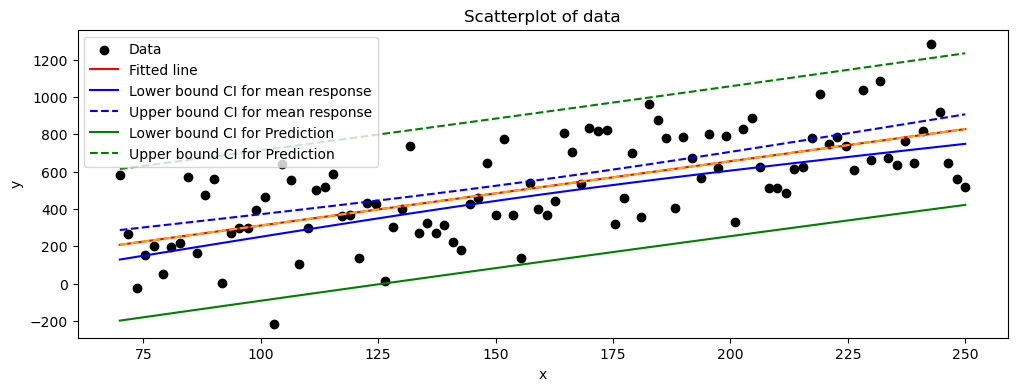

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.453
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     81.08
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.75e-14
Time:                        17:55:26   Log-Likelihood:                -671.14
No. Observations:                 100   AIC:                             1346.
Df Residuals:                      98   BIC:                             1351.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -33.5679     64.440     -0.521      0.6

In [222]:
# Generate data
np.random.seed(1508) # for reproducibility
n, p = 100, 1 # n is sample size and p numbers of features
x = np.linspace(70,250,n) # feature 
X_design = np.hstack([np.ones(n).reshape(n,1),x.reshape(n,1)]) # design matrix with intercept
df_res = n - X_design.shape[1] # degrees of freedom of residuals
theta_true = np.random.randint(1,10,X_design.shape[1])
print("True parameters:",theta_true, " and degrees of freedom of residuals:",df_res)
error = np.random.randn(n)*200
y = X_design @ theta_true + error


# Ordinary Least Squares
theta_hat = np.linalg.pinv(X_design) @ y # same as np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y but more stable
print("Estimated theta:",theta_hat)
#model_OLS = LinearRegression(fit_intercept=True).fit(x.reshape(n,1),y)
#print("Estimated theta via library:",np.array([model_OLS.intercept_,*model_OLS.coef_]))
#X_design = sm.add_constant(x) # add intercept via library
model_OLS = sm.OLS(y,X_design).fit()
print("Estimated theta via library:",model_OLS.params)



# Predictions
y_hat = X_design @ theta_hat
y_hat_library = model_OLS.fittedvalues

# log likelihood
def log_likelihood(y, X, theta, sigma2):
    n = len(y)
    residuals = y - X @ theta
    SSE = np.sum(residuals**2)
    
    return - (n/2)*np.log(2*np.pi*sigma2) - (1/(2*sigma2))*SSE


# ----- Statistics -----
y_mean = np.mean(y)
SST = np.sum((y-y_mean)**2)
SSR = np.sum((y_hat - y_mean)**2)
SSE = np.sum((y - y_hat)**2)

# Model score
R2 = SSR / SST
R2_adj = 1 - ((n-1)/(n-X_design.shape[1]))*(1-R2)
print(f"Model score is {np.round(R2,3)}")
print(f"Adjusted Model score is {np.round(R2_adj,3)}")

# theta covariance
SSE_var = SSE / df_res
print(f"Sample variance:{np.round(SSE_var,3)}")
theta_cov = SSE_var * np.linalg.pinv(X_design.T @ X_design) # np.linalg.pinv(X_design.T @ X_design) better than np.linalg.inv(X_design.T @ X_design)
print(f"Covariance of parameters:\n{theta_cov}")
print(f"Standard deviation of parameters:{np.round(np.sqrt(np.diag(theta_cov)),3)}")


log_like = log_likelihood(y,X_design,theta_hat,SSE_var)
print(f"log-liekelihood: {log_like:.2f}")

# t tests for H0:theta_0 = 0 and H0:theta_1 = 0
t0 = theta_hat[0] / np.sqrt(theta_cov[0,0])
t1 = theta_hat[1] / np.sqrt(theta_cov[1,1])
alpha = .05
print(f"t0 = {t0:.3f} with p-value {2 * (1 - stats.t.cdf(np.abs(t0), df_res)):.3f} and t1={t1:.3f} with p-value {2 * (1 - stats.t.cdf(np.abs(t1), df_res)):.3f}")
t_crit = stats.t.ppf(1 - alpha/2, df_res)
intercept_range = [theta_hat[0] - t_crit*np.sqrt(theta_cov[0,0]), theta_hat[0] + t_crit*np.sqrt(theta_cov[0,0])]
print(f"Confidence interval for intercept:\n{intercept_range}")
x1_range = [theta_hat[1] - t_crit*np.sqrt(theta_cov[1,1]), theta_hat[1] + t_crit*np.sqrt(theta_cov[1,1])]
print(f"Confidence interval for feature:\n{x1_range}")


# F tests for H0:intercept=0
theta_hat_no_bias = np.linalg.pinv(x.reshape(n,1)) @ y
SSE_restricted = np.sum((y - x.reshape(n,1)@theta_hat_no_bias)**2)
q = 1 # number of restrictions
F_intercept = ((SSE_restricted - SSE)/q) / (SSE / df_res) # F test for intercept=0
print(f"F-statistic manually for H0:intercept=0: {F_intercept} and p-value={1 - f.cdf(F_intercept,q,df_res)}  or via library: {model_OLS.f_test("const=0")}")


# F tests for H0:x1 = 0
theta_hat_no_feature = np.linalg.pinv(np.ones((n,1))) @ y
SSE_restricted = np.sum((y - x.reshape(n,1)@theta_hat_no_feature)**2)
SSE_restricted = SST
q = 1 # number of restrictions
#F_x1 = (SSR/q) / (SSE / df_res) # F test for x1=0
F_x1 = ((SSE_restricted - SSE)/q) / (SSE / df_res) # F test for x1=0
print(f"F-statistic manually for H0:x1=0: {F_x1} and p-value={1 - f.cdf(F_x1,q,df_res)} or via library: {model_OLS.f_test("x1=0")}")


# F tests for H0:intercept=x1=0
SSE_restricted = np.sum((y-0)**2)
q = 2 # number of restrictions
F_int_x1 = ((SSE_restricted - SSE)/q) / (SSE / df_res) # F test for intercept=0
print(f"F-statistic manually for H0:intercept=x1=0: {F_int_x1} and p-value={1 - f.cdf(F_int_x1,q,df_res)}  or via library: {model_OLS.f_test("const=x1=0")}")


# Confidence interval for mean response
XtX_inv = np.linalg.pinv(X_design.T @ X_design)
CI_mean = np.array([[
    X_design[i] @ theta_hat - t_crit * np.sqrt(SSE_var * X_design[i].T @ XtX_inv @ X_design[i]),
    X_design[i] @ theta_hat + t_crit * np.sqrt(SSE_var * X_design[i].T @ XtX_inv @ X_design[i])] for i in range(n)])


# Prediction interval
CI_pred = np.array([[
    X_design[i] @ theta_hat - t_crit * np.sqrt(SSE_var * (1 + X_design[i].T @ XtX_inv @ X_design[i])),
    X_design[i] @ theta_hat + t_crit * np.sqrt(SSE_var * (1 + X_design[i].T @ XtX_inv @ X_design[i]))] for i in range(n)])

# Plot data
plt.figure(figsize=(12,4))
plt.scatter(X_design[:,1],y,label="Data",color="black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatterplot of data")
plt.plot(x,y_hat,color="red",label="Fitted line")
plt.plot(x,y_hat_library,color="orange",linestyle="--")
plt.plot(x,CI_mean[:,0],color="blue",label="Lower bound CI for mean response")
plt.plot(x,CI_mean[:,1],color="blue",label="Upper bound CI for mean response",linestyle="--")
plt.plot(x,CI_pred[:,0],color="green",label="Lower bound CI for Prediction")
plt.plot(x,CI_pred[:,1],color="green",label="Upper bound CI for Prediction",linestyle="--")

plt.legend()
plt.show()
print(model_OLS.summary())

In [219]:
CI_mean[:,0]

array([128.5166891 , 135.97148028, 143.41987074, 150.86155982,
       158.29622959, 165.72354379, 173.14314663, 180.55466164,
       187.9576903 , 195.35181075, 202.73657635, 210.11151415,
       217.4761234 , 224.82987388, 232.17220426, 239.50252033,
       246.82019333, 254.12455809, 261.4149113 , 268.69050972,
       275.9505685 , 283.19425951, 290.42070988, 297.62900062,
       304.81816556, 311.9871905 , 319.13501282, 326.26052144,
       333.36255744, 340.43991527, 347.49134471, 354.51555375,
       361.51121243, 368.47695779, 375.41139999, 382.31312979,
       389.1807273 , 396.0127721 , 402.8078548 , 409.56458978,
       416.28162912, 422.9576775 , 429.59150778, 436.18197688,
       442.72804166, 449.22877429, 455.68337664, 462.09119319,
       468.45172206, 474.76462367, 481.02972668, 487.24703111,
       493.41670827, 499.53909775, 505.61470143, 511.64417483,
       517.62831608, 523.56805302, 529.46442877, 535.31858642,
       541.13175311, 546.90522417, 552.6403475 , 558.33

<a class="anchor" id="gd"></a>
## 6. (Batch) Gradient Descent 

**Gradient Descent** (or Batch Gradient Descent) is an iterative optimization algorithm used to **minimize the Sum of Squared Errors (SSE)** in a multiple linear regression model.  

Here, the SSE is defined as:

$$
\text{SSE}(\theta) = \sum_{i=1}^{n} \big(y^{(i)} - \hat{y}^{(i)}\big)^2 
= \sum_{i=1}^{n} \big(y^{(i)} - \theta^\top x^{(i)}\big)^2
= \lVert y - X\theta \rVert_2^2
$$

---

### Gradient Descent Procedure

Instead of checking all possible parameter combinations, we iteratively update the parameter vector 

$$
\theta = (\theta_0, \theta_1, \dots, \theta_p)^\top
$$

1. **Initialize** $\theta^{[0]}$ randomly (or using zeros).  

2. **Compute the gradient** of the SSE with respect to $\theta$:

$$
\nabla_\theta \text{SSE}(\theta) 
= \frac{\partial \text{SSE}}{\partial \theta} 
= -2 X^\top (y - X\theta)
$$

- Each component indicates the direction of steepest increase in SSE.  
- To **reduce error**, we move in the opposite direction.

3. **Update parameters** using the learning rate $\alpha > 0$:

$$
\theta^{[t+1]} = \theta^{[t]} - \alpha \, \nabla_\theta \text{SSE}(\theta^{[t]})
$$

4. **Repeat** until convergence:  

- Change in $\theta$ is very small, or  
- Gradient approaches zero: 
$
\lVert \nabla_\theta \text{SSE}(\theta^{[t]}) \rVert \approx 0
$

---

### Local vs Global Minimum

- **Local minimum**: a point where small changes in $\theta$ increase SSE, but it may not be the lowest possible SSE overall.  
- **Global minimum**: the point with the lowest SSE across the entire parameter space.  
- **Stationary point**: gradient equals zero ($\nabla_\theta \text{SSE} = 0$).  
- Gradient descent may stop at:
  - Global minimum  
  - Local minimum (rare for linear SSE)  
  - Saddle point  

For linear regression, **SSE is convex**, so any stationary point is the **global minimum**.


<p align="center">
<img src="local_global_min.jpg" width="350"/>
</p>


---

### Conditions for Minimum

Given SSE is continuously differentiable with respect to $\theta$:

1. **Stationarity**:  

$$
\nabla_\theta \text{SSE}(\hat{\theta}) = 0
$$

2. **Positive definite Hessian** (second derivative):  

$$
z^\top \nabla^2_\theta \text{SSE}(\hat{\theta}) \, z \ge 0 \quad \forall z \neq 0
$$  

- For multiple linear regression, the Hessian is 

$$
\nabla^2_\theta \text{SSE} = 2 X^\top X
$$

which is **positive semi-definite**, ensuring gradient descent converges to the global minimum.

---

### Learning Rate $\alpha$

- **Small $\alpha$** $\rightarrow$ slow convergence, but stable  
- **Good $\alpha$** $\rightarrow$ fast convergence, stable updates  
- **Too large $\alpha$** $\rightarrow$ overshoot, possible divergence  

---

### Limitations of Batch Gradient Descent

- **High computational cost**: computing $X^\top (y - X\theta)$ for all $n$ observations at each iteration  
- **Memory intensive**: full dataset must fit in memory  
- **Slow updates**: no parameter updates until full dataset is processed  

---

### Stochastic Gradient Descent (SGD)

SGD addresses these limitations by updating $\theta$ **using one data point (or mini-batch) at a time**:

$$
\theta^{[t+1]} = \theta^{[t]} - \alpha \, \nabla_\theta \big(y^{(i)} - \theta^\top x^{(i)}\big)^2
$$

Benefits:

- Much faster updates  
- Can scale to very large datasets  
- Lower memory usage  
- Adds randomness that can help escape saddle points  

Trade-off:

- **SGD is faster but noisier**  
- **Batch GD is stable but slower**  

$$
\begin{align*}
\frac{\partial \text{SSE}}{\partial \theta_j} 
&= \frac{\partial}{\partial \theta_j} \sum_{i=1}^{n} \big(y^{(i)} - \theta^\top x^{(i)}\big)^2 \\
&= \sum_{i=1}^{n} \frac{\partial}{\partial \theta_j} \big(y^{(i)} - \theta^\top x^{(i)}\big)^2 \\
&= \sum_{i=1}^{n} 2 \big(y^{(i)} - \theta^\top x^{(i)}\big) \frac{\partial}{\partial \theta_j} \big(y^{(i)} - \theta^\top x^{(i)}\big) \\
&= \sum_{i=1}^{n} 2 \big(y^{(i)} - \theta^\top x^{(i)}\big) (-x^{(i)}_j) \\
&= -2 \sum_{i=1}^{n} x^{(i)}_j \big(y^{(i)} - \theta^\top x^{(i)}\big)
\end{align*}
$$

or in matrix form

$$
\begin{align*}
\frac{\partial \text{SSE}}{\partial \theta}
&=\frac{\partial}{\partial \theta} (y-X\theta)^\top (y-X\theta) \\
&= \frac{\partial}{\partial \theta} (y^\top y - y^\top X\theta - (X\theta)^\top y + (X\theta)^\top X\theta) \\
&= \frac{\partial}{\partial \theta} (y^\top y - y^\top X\theta - \theta^\top X^\top y + \theta^\top X^\top X\theta) \\
&= \frac{\partial}{\partial \theta} (y^\top y - 2y^\top X\theta + \theta^\top X^\top X\theta) \\
&=  - 2y^\top X + 2 \theta^\top X^\top X \\
&=  - 2 (y^\top X - \theta^\top X^\top X) \\
&=  - 2  (X^\top y -  X^\top X \theta) \\
&=  - 2 X^\top  ( y -  X \theta) \\
\end{align*} 
$$


$$
\nabla_\theta \text{SSE}(\theta) = 
\begin{pmatrix}
\frac{\partial \text{SSE}}{\partial \theta_0} \\
\frac{\partial \text{SSE}}{\partial \theta_1} \\
\vdots \\
\frac{\partial \text{SSE}}{\partial \theta_p}
\end{pmatrix}
= -2 X^\top (y - X\theta)
$$

In [22]:
# Generate data
np.random.seed(2047) # for reproducibility of random numbers
n = 200
X=np.random.uniform(1,100,2*n).reshape(n,2)
X=np.column_stack([np.ones(n),X])
true_theta=np.random.randint(1,5,3) 
sigma=80
error = np.random.randn(n) * sigma # same as np.random.normal(loc=0,scale=sigma,size=n)
y = X @ true_beta + error

# Plot data points
fig1 = px.scatter_3d(x=X[:,1], y=X[:,2], z=y,title="Data",labels={'x':'Feature1','y':'Feature2','z':'Target'})
fig1.update_layout(width=700, height=500)
fig1.show()

# SSE function
def SSE(X,y,theta):
    return (y-X @ theta).T @ (y-X @ theta)

def gradien(X,y,theta):
    return -2 * X.T @ (y - X @ theta)


# Grid for theta_1 and theta_2 (fix theta_0)
theta0_fixed = 2
theta1_vals = np.linspace(true_theta[1]-50, true_theta[1]+50, 40)
theta2_vals = np.linspace(true_theta[2]-50, true_theta[2]+50, 40)

T1, T2 = np.meshgrid(theta1_vals, theta2_vals)
Z = np.zeros_like(T1)

for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        th = np.array([theta0_fixed, T1[i,j], T2[i,j]])
        Z[i,j] = SSE(X, y, th)


# Plot SSE surface using plotly.express as px and plotly.graph_objects as go
fig2 = go.Figure(data=[go.Surface(x=T1, y=T2, z=Z, colorscale='Viridis', opacity=0.8)])
fig2.update_layout(
    title=f"SSE Surface (intercept fixed at {theta0_fixed})",
    scene=dict(
        xaxis_title=f"feature 1",
        yaxis_title="feature 2",
        zaxis_title="SSE"
    ),
    width=700,
    height=500
)

fig2.show()

fig2 = px.imshow(
    Z,
    x=theta1_vals,
    y=theta2_vals,
    color_continuous_scale='viridis',
    labels=dict(x='feature 1', y="feature 2", color='SSE'),
    title=f"SSE Surface (intercept fixed at {theta0_fixed})"
)

fig2.update_layout(width=700, height=500)
fig2.show()

fig2 = px.scatter_3d(
    x=T1.flatten(),
    y=T2.flatten(),
    z=Z.flatten(),
    color=Z.flatten(),
    color_continuous_scale='viridis',
    labels={'x': 'feature 1', 'y': 'feature 2', 'z': 'SSE'},
    title=f"SSE Surface (intercept fixed at {theta0_fixed})"
)

fig2.update_traces(marker=dict(size=3))
fig2.update_layout(width=700, height=500)

fig2.show()


In [23]:
# Generate data
np.random.seed(1050)
n = 50
X = np.random.randn(2*n).reshape(n, 2)
X = np.column_stack([np.ones(n), X])

error = np.random.normal(0, 2, n)
true_theta = np.random.uniform(0, 4, X.shape[1])
y = X @ true_theta + error


# Gradient
def gradient(X, y, theta):
    return -2 * X.T @ (y - X @ theta)


# Gradient Descent
alpha = 1e-3 # learning rate
max_iter = 5000 # maximum iterations for gradient descent for loop
theta = np.random.uniform(0, 2, X.shape[1]) # randomly select start parameters

theta_history = [theta.copy()] # history of thetas (store theta.copy() because storing only theta means storing a reference)
epsilon = 1e-6 # tolerance

for t in range(max_iter):
    slope = gradient(X, y, theta)
    theta = theta - alpha * slope
    theta_history.append(theta.copy())

    if np.linalg.norm(theta - theta_history[-2]) < epsilon: # if change in new parameters is very small
        print(f"Converged in {t} iterations")
        break

print("Estimated theta:", theta_history[-1])
print("True theta:", true_theta)

# Plot data points
fig = px.scatter_3d(x=X[:,1], y=X[:,2], z=y,title="Data",labels={'x':'x1','y':'x2','z':'y'})


# choose distinct colors
colors = pc.qualitative.Plotly  # nice default palette

for idx, i in enumerate([0, 10, 20, 100, 150, 184]):
    
    # Grid
    grid_x1, grid_x2 = np.meshgrid(
        np.linspace(X[:,1].min(), X[:,1].max(), 30),
        np.linspace(X[:,2].min(), X[:,2].max(), 30)
    )

    grid_X = np.column_stack((
        np.ones(grid_x1.size),
        grid_x1.ravel(),
        grid_x2.ravel()
    ))

    # Predictions
    surface_pred = (grid_X @ theta_history[i]).reshape(grid_x1.shape)

    # Pick color
    color = colors[idx % len(colors)]

    # Create constant colorscale
    colorscale = [[0, color], [1, color]]

    fig.add_trace(go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=surface_pred,
        opacity=0.5,
        showscale=False,
        colorscale=colorscale,
        name=f"Iteration {i}",
        showlegend=True
    ))


fig.update_layout(width=700, height=500)
fig.show()

Converged in 183 iterations
Estimated theta: [2.66759505 2.91525333 2.84807047]
True theta: [2.69116462 2.95127721 2.74973213]


<a class="anchor" id="sgd"></a>
## 7. Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent (SGD) is a variant of gradient descent that updates the parameter vector $\theta$ using only **one observation** (or a small subset) at each iteration.

Instead of computing the gradient over the full dataset, we approximate the risk using a single data point $i$:

$$
\text{SSE}_i(\theta) = \big(y^{(i)} - \theta^\top x^{(i)}\big)^2
$$

---

### SGD Procedure

1. **Initialize** $\theta^{[0]}$ randomly (or with zeros).

2. **At each iteration**, randomly select a data point $(x^{(i)}, y^{(i)})$.

3. **Compute the gradient** using only this observation:

$$
\frac{\partial \text{SSE}_i}{\partial \theta} 
= -2 x^{(i)} \big(y^{(i)} - \theta^\top x^{(i)}\big)
$$

- Gradient vector:

$$
\nabla_\theta \text{SSE}_i =
\begin{pmatrix}
\frac{\partial \text{SSE}_i}{\partial \theta_0} \\
\frac{\partial \text{SSE}_i}{\partial \theta_1} \\
\vdots \\
\frac{\partial \text{SSE}_i}{\partial \theta_p}
\end{pmatrix}
= -2 x^{(i)} \big(y^{(i)} - \theta^\top x^{(i)}\big)
$$

4. **Update parameters** using this noisy gradient:

$$
\theta^{[t+1]} = \theta^{[t]} - \alpha \, \nabla_\theta \text{SSE}_i(\theta^{[t]})
$$

Where:

- $\alpha$ = learning rate  
- Gradient is now based on **one observation**, not the full dataset  
- Updates are **noisy approximations** of the true gradient

5. **Repeat** until convergence:

- Continue sampling observations and updating $\theta$  
- Convergence is reached when $\theta$ stabilizes **on average**  
- The path oscillates around the minimum rather than smoothly converging

---

### Comparison to Batch Gradient Descent

<div style="display:flex; gap:20px;"> 

<div style="padding:16px; width:50%;">

**Batch Gradient Descent**

- Uses all data points  
- Smooth convergence  
- Computationally expensive  
</div> 

<div style="padding:16px; width:50%;">

**Stochastic Gradient Descent**

- Uses one data point at a time  
- Noisy updates  
- Much faster and scalable  
</div> 

</div>

---

### Mini-batch Gradient Descent (Practical Compromise)

In practice, we often use **mini-batch gradient descent**, which updates parameters using a small batch of observations $\mathcal{B}$:

$$
\theta^{[t+1]} = \theta^{[t]} - \alpha \, \nabla_\theta \text{SSE}_\mathcal{B}(\theta^{[t]})
$$

- $\mathcal{B}$ = subset of observations in the mini-batch  
- Reduces noise while still allowing faster updates than full batch

---

### Key Takeaway

- **Batch GD**: smooth, stable, but slower updates  
- **SGD**: noisy, fast, can reach a good solution quickly  
- **Mini-batch GD**: combines benefits of both approaches

In [24]:
# Generate data
np.random.seed(1050)
n = 50
X = np.random.randn(2*n).reshape(n, 2)
X = np.column_stack([np.ones(n), X])

error = np.random.normal(0, 2, n)
true_theta = np.random.uniform(0, 4, X.shape[1])
y = X @ true_theta + error


# SGD Gradient (single sample)
def gradient_i(x_i, y_i, theta):
    return -2 * x_i * (y_i - x_i @ theta)


# Stochastic Gradient Descent
alpha = 1e-3
max_iter = 5000
theta = np.random.uniform(0, 2, X.shape[1])

theta_history = [theta.copy()]
epsilon = 1e-6

for t in range(max_iter):

    # pick random observation
    i = np.random.randint(0, n)
    x_i = X[i] # extract single row
    y_i = y[i]

    # compute stochastic gradient
    slope = gradient_i(x_i, y_i, theta)

    # update
    theta = theta - alpha * slope
    theta_history.append(theta.copy())

    # convergence check (still works as rough stopping rule)
    if np.linalg.norm(theta - theta_history[-2]) < epsilon:
        print(f"Converged in {t} iterations")
        break

print("Estimated theta:", theta_history[-1])
print("True theta:", true_theta)


# Plot data
fig = px.scatter_3d(
    x=X[:,1], y=X[:,2], z=y,
    title="SGD: Data and Fitted Planes",
    labels={'x':'x1','y':'x2','z':'y'}
)


# Plot planes 
colors = pc.qualitative.Plotly

# safer index selection
indices = np.linspace(0, len(theta_history)-1, 6, dtype=int)

for idx, i in enumerate(indices):

    grid_x1, grid_x2 = np.meshgrid(
        np.linspace(X[:,1].min(), X[:,1].max(), 30),
        np.linspace(X[:,2].min(), X[:,2].max(), 30)
    )

    grid_X = np.column_stack((
        np.ones(grid_x1.size),
        grid_x1.ravel(),
        grid_x2.ravel()
    ))

    surface_pred = (grid_X @ theta_history[i]).reshape(grid_x1.shape)

    color = colors[idx % len(colors)]
    colorscale = [[0, color], [1, color]]

    fig.add_trace(go.Surface(
        x=grid_x1,
        y=grid_x2,
        z=surface_pred,
        opacity=0.5,
        showscale=False,
        colorscale=colorscale,
        name=f"Iteration {i}",
        showlegend=True
    ))

fig.update_layout(width=700, height=500)
fig.show()

Estimated theta: [2.70003476 2.92340587 2.84682432]
True theta: [2.69116462 2.95127721 2.74973213]


<a class="anchor" id="limits"></a>
## 8. Limitations

While **Multiple Linear Regression** is a powerful and widely used model, it has several important limitations.

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Multicollinearity</u></h5>

A key limitation arises when the features are **highly correlated** or linearly dependent. This situation is known as **multicollinearity**.

In matrix terms, this means that the design matrix $X$ does **not have full column rank**, i.e.:

$$
\text{rank}(X) < p + 1
$$

where $p+1$ is the number of columns (including the intercept).

---

#### Consequence: Non-unique solutions

If $X$ is not full rank, then there exists a non-zero vector $v \in \text{Null}(X)$ such that:

$$
Xv = 0
$$

This implies that for any scalar $t \in \mathbb{R}$:

$$
X(\hat{\theta} + t v) = X\hat{\theta} + t Xv = X\hat{\theta}
$$

Therefore, all parameter vectors of the form:

$$
\hat{\theta} + t v
$$

produce the **same predictions**.

---

#### Problem: Unbounded coefficients

Since $t$ can be arbitrarily large, the parameter estimates can grow without bound:

$$
\|\hat{\theta} + t v\| \rightarrow \infty \quad \text{as} \quad |t| \rightarrow \infty
$$

- The model predictions remain unchanged  
- But the coefficients become extremely large and unstable  

This leads to:

- High variance in estimates  
- Sensitivity to small changes in data  
- Poor interpretability  

---

### Regularization as a Solution

A common way to address this issue is to **restrict the size of the coefficients**.

This leads to **regularized regression methods**:

#### Ridge Regression ($\ell_2$ regularization)

$$
\hat{\theta}^{\text{ridge}} = \arg\min_\theta \left\{ \|y - X\theta\|^2 + \lambda \|\theta\|^2 \right\}
$$

- Penalizes large coefficients  
- Ensures a **unique solution** even when $X^\top X$ is not invertible  

---

#### Lasso Regression ($\ell_1$ regularization)

$$
\hat{\theta}^{\text{lasso}} = \arg\min_\theta \left\{ \|y - X\theta\|^2 + \lambda \|\theta\|_1 \right\}
$$

- Encourages **sparse solutions** (some coefficients become exactly zero)  
- Performs **feature selection** 

* <a href="../4.Ridge,Lasso%20and%20Elastic%20Net%20Regression/Ridge,Lasso%20and%20Elastic%20Net.ipynb">Check out the notebook on Ridge,Lasso and Elastic Net Regression</a>

---

### Key Takeaway

- Multicollinearity leads to **non-unique and unstable parameter estimates**  
- The problem arises when $\text{rank}(X) < p+1$  
- Regularization (Ridge / Lasso) stabilizes the solution by **penalizing large coefficients**

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Linearity Assumption</u></h5>

Multiple Linear Regression assumes that the relationship between features and target is **linear in the parameters**:

$$
y^{(i)} = \theta^\top x^{(i)} + \varepsilon^{(i)}
$$

This can be too restrictive in practice.

---

#### Problem: Nonlinear relationships

If the true relationship is nonlinear, a linear model may:

- Underfit the data  
- Miss important patterns  

---

#### Solution:Multivariate Polynomial Regression

We can extend the model by introducing nonlinear transformations of the features.

For example, with two features:

$$
y^{(i)} = \theta_0 + \theta_1 x_1^{(i)} + \theta_2 x_2^{(i)} + \theta_3 (x_1^{(i)})^2 + \theta_4 (x_2^{(i)})^2 + \theta_5 x_1^{(i)} x_2^{(i)} + \varepsilon^{(i)}
$$

This is still a **linear model in the parameters**, but allows for **nonlinear relationships in the features**.


<a href="../3.(Multivariate)%20Polynomial%20Regression/(Multivariate)%20Polynomial%20Regression.ipynb">Check out the notebook on (Multivariate) Polynomial Regression</a>



</div>

</div>

### Summary

- Multicollinearity leads to **non-unique and unstable parameter estimates**  
- Coefficients can become arbitrarily large without affecting predictions  
- Regularization (Ridge/Lasso) resolves this by penalizing large coefficients  
- The model is limited to **linear relationships**, requiring feature transformations for nonlinear data  